# 08 - Target Comparison: Price vs Log-Price and Model Comparision

This notebook compares two modeling strategies for laptop price prediction:

- **Direct price modeling**: models trained on `target_price` (original price scale)
- **Log-price modeling**: models trained on `log_target_price` (log-transformed scale)

## Objective

Evaluate whether training on `log_target_price` yields better or worse predictions than training directly on `target_price`, when both are assessed on the **original price scale**.

## Key Principle

All comparisons are performed on the **original price scale** (VND or the dataset's native price unit). For models trained on `log_target_price`, predictions are converted back to the price scale using the inverse transform (`np.expm1` for `log1p`) **before** computing any error metrics. This ensures a fair, apples-to-apples comparison.

## Source of Data

This notebook loads saved artifacts from `artifacts/modeling/` produced by notebook `07_modeling`. Model retraining is only triggered if required artifacts are missing or inconsistent.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ── Configuration (must match notebook 07) ────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE = 0.20
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True
CLOSE_WIN_THRESHOLD = 0.02  # differences below 2% are treated as a close result

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed.csv'

ARTIFACT_DIR        = PROJECT_ROOT / 'artifacts' / 'modeling_numeric'
METRICS_DIR         = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR     = ARTIFACT_DIR / 'predictions'
MODELS_DIR          = ARTIFACT_DIR / 'models'
PLOTS_DIR           = ARTIFACT_DIR / 'plots'
COMPARISON_DIR      = ARTIFACT_DIR / 'target_comparison'

COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'DATA_PATH     : {DATA_PATH}')
print(f'ARTIFACT_DIR  : {ARTIFACT_DIR}')
print(f'COMPARISON_DIR: {COMPARISON_DIR}')

PROJECT_ROOT  : Y:\Python\Laptop-Price-Prediction
DATA_PATH     : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
ARTIFACT_DIR  : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric
COMPARISON_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\target_comparison


## 2. Helper Functions

In [2]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y = np.asarray(y_pred_log, dtype=float)
    if method == 'log1p':
        y_price = np.expm1(y)
    elif method == 'log':
        y_price = np.exp(y)
    else:
        raise ValueError("method must be 'log1p' or 'log'")
    if CLIP_NEGATIVE_PREDICTIONS:
        y_price = np.maximum(y_price, 0.0)
    return y_price


def calculate_metrics(y_true, y_pred) -> Dict[str, float]:
    """Return a dict of regression metrics (price scale)."""
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    rmsle = np.sqrt(np.mean((np.log1p(np.maximum(yp, 0)) - np.log1p(np.maximum(yt, 0))) ** 2))
    return {
        'mae'                : mean_absolute_error(yt, yp),
        'rmse'               : root_mean_squared_error(yt, yp),
        'r2'                 : r2_score(yt, yp),
        'mape'               : mean_absolute_percentage_error(yt, yp),
        'median_absolute_error': median_absolute_error(yt, yp),
        'max_error'          : max_error(yt, yp),
        'rmsle'              : rmsle,
    }


def winner_lower(a, b, name_a='target_price', name_b='log_target_price'):
    """Return the name of the better option (lower is better)."""
    if b < a:
        return name_b
    elif a < b:
        return name_a
    return 'tie'


def winner_higher(a, b, name_a='target_price', name_b='log_target_price'):
    """Return the name of the better option (higher is better)."""
    if b > a:
        return name_b
    elif a > b:
        return name_a
    return 'tie'


def pct_diff(new_val, ref_val):
    """Percentage difference of new_val vs ref_val."""
    if ref_val == 0:
        return np.nan
    return (new_val - ref_val) / ref_val


print('Helper functions defined.')

Helper functions defined.


## 3. Load Artifacts from Notebook 07

We first inspect what CSV files are available in `metrics/` and `predictions/`, then load the most relevant ones. We validate that both `target_price` and `log_target_price` results are present.

In [3]:
# ── Discover available files ──────────────────────────────────────────────────
metrics_csvs     = sorted(METRICS_DIR.glob('*.csv'))
predictions_csvs = sorted(PREDICTIONS_DIR.glob('*.csv'))

print('=== Metrics files ===')
for f in metrics_csvs:
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in predictions_csvs:
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [4]:
# ── Load metrics ──────────────────────────────────────────────────────────────
METRICS_FILE_CANDIDATES = ['model_metrics.csv', 'metrics_df.csv', 'all_metrics.csv']
metrics_raw = None
selected_metrics_file = None

for candidate in METRICS_FILE_CANDIDATES:
    path = METRICS_DIR / candidate
    if path.exists():
        metrics_raw = pd.read_csv(path)
        selected_metrics_file = path
        break

# Fallback: try any CSV that contains both target values
if metrics_raw is None:
    for f in metrics_csvs:
        try:
            df_try = pd.read_csv(f)
            cols_lower = [c.lower() for c in df_try.columns]
            if any('target' in c for c in cols_lower) and any('model' in c for c in cols_lower):
                metrics_raw = df_try
                selected_metrics_file = f
                break
        except Exception:
            continue

if metrics_raw is None:
    raise FileNotFoundError(
        'No suitable metrics CSV found in ' + str(METRICS_DIR) +
        '. Please run notebook 07_modeling first to generate model_metrics.csv.'
    )

print(f'Loaded metrics from: {selected_metrics_file.name}')
print(f'Shape: {metrics_raw.shape}')
display(metrics_raw.head())

Loaded metrics from: model_metrics.csv
Shape: (16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.4705,5.4785,0.8653,0.3302,2.1144,36.2442,8.0484,0.0041
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4455,5.6434,0.8571,0.2899,1.9306,37.5938,7.9994,0.0034
2,LightGBM,gradient_boosting,target_price,target_price,3.5269,5.7620,0.8511,0.3200,1.9498,38.6261,1.0455,0.0191
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4375,5.7633,0.8510,0.2893,1.8491,38.5314,1.7507,0.0211
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5388,5.8795,0.8449,0.3051,1.9392,36.1898,1.8360,0.1520


In [5]:
# ── Load predictions ──────────────────────────────────────────────────────────
PREDICTIONS_FILE_CANDIDATES = ['test_predictions.csv', 'predictions_df.csv', 'all_predictions.csv']
predictions_raw = None
selected_predictions_file = None

for candidate in PREDICTIONS_FILE_CANDIDATES:
    path = PREDICTIONS_DIR / candidate
    if path.exists():
        predictions_raw = pd.read_csv(path)
        selected_predictions_file = path
        break

if predictions_raw is None:
    for f in predictions_csvs:
        try:
            df_try = pd.read_csv(f)
            if any('pred' in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                selected_predictions_file = f
                break
        except Exception:
            continue

if predictions_raw is not None:
    print(f'Loaded predictions from: {selected_predictions_file.name}')
    print(f'Shape: {predictions_raw.shape}')
    display(predictions_raw.head())
else:
    print('WARNING: No predictions CSV found. Prediction-level analysis will be skipped.')

Loaded predictions from: test_predictions.csv
Shape: (1442, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,308,9.0000,9.6641,7.5611,9.6946,7.5296,9.6908,7.6658,9.6976,7.6043,6.7468,6.2711,6.9308,6.4150,6.9120,6.5745,8.7198,6.9512
1,381,10.5000,10.6328,8.0600,10.4302,7.9252,10.4369,7.8958,10.4315,7.9140,9.0842,8.8218,9.0997,8.8671,9.1409,8.7900,8.9843,8.5053
2,1839,2.0000,4.6875,5.6674,4.6735,5.8175,4.6646,5.8844,4.6578,5.8550,2.8033,2.7044,3.1748,2.8450,3.7969,3.3711,3.8885,3.5125
3,3438,11.5000,13.9141,13.7706,13.8621,13.2717,13.8765,13.0689,13.8730,13.1694,12.8945,12.6684,12.8956,12.6720,13.4430,13.5301,13.0165,13.0666
4,251,9.2000,10.0234,8.0423,10.2500,8.1516,10.2458,8.0850,10.2675,8.1148,8.2383,7.6625,10.1611,6.7065,9.5467,9.0143,9.2180,8.5379


## 4. Artifact Validation

We verify that the metrics file contains the required columns and that both target types are present.

In [6]:
# ── Standardize column names ──────────────────────────────────────────────────
metrics_raw.columns = [
    c.strip().lower().replace(' ', '_').replace('-', '_')
    for c in metrics_raw.columns
]

# Rename known alias columns
rename_map = {
    'median_ae': 'median_absolute_error',
    'train_time_sec': 'training_time_seconds',
    'predict_time_sec': 'predict_time_seconds',
}
metrics_raw.rename(columns=rename_map, inplace=True)

print('Standardized columns:', metrics_raw.columns.tolist())

# ── Validate required columns ─────────────────────────────────────────────────
required_cols = ['model_name', 'target_used', 'mae', 'rmse', 'r2']
missing_cols = [c for c in required_cols if c not in metrics_raw.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in metrics: {missing_cols}')

# ── Validate both target types are present ────────────────────────────────────
targets_present = set(metrics_raw['target_used'].unique())
print(f'\nTargets present: {targets_present}')

has_price    = 'target_price'     in targets_present
has_logprice = 'log_target_price' in targets_present

if not has_price:
    print('WARNING: target_price results not found in metrics.')
if not has_logprice:
    print('WARNING: log_target_price results not found in metrics.')

if has_price and has_logprice:
    print('✓ Both target_price and log_target_price results found. Proceeding.')

Standardized columns: ['model_name', 'model_type', 'target_used', 'evaluation_scale', 'mae', 'rmse', 'r2', 'mape', 'median_absolute_error', 'max_error', 'training_time_seconds', 'predict_time_seconds']

Targets present: {'log_target_price', 'target_price'}
✓ Both target_price and log_target_price results found. Proceeding.


## 5. Clean and Standardize Metrics

We create a clean `metrics_df` with a readable label column, and separate subsets for each target type.

In [7]:
metrics_df = metrics_raw.copy()

# Ensure mape is expressed as a fraction (0–1 range), not percentage
if 'mape' in metrics_df.columns:
    if metrics_df['mape'].max() > 10:  # if stored as percentage like 23.4 instead of 0.234
        metrics_df['mape'] = metrics_df['mape'] / 100.0

# Add human-readable label
label_map = {
    'target_price'     : 'Price target',
    'log_target_price' : 'Log-price target',
}
metrics_df['target_label'] = metrics_df['target_used'].map(label_map).fillna(metrics_df['target_used'])

price_metrics_df    = metrics_df[metrics_df['target_used'] == 'target_price'].copy()
logprice_metrics_df = metrics_df[metrics_df['target_used'] == 'log_target_price'].copy()

print(f'Total rows: {len(metrics_df)}')
print(f'  target_price rows    : {len(price_metrics_df)}')
print(f'  log_target_price rows: {len(logprice_metrics_df)}')
print()
display(metrics_df[['model_name', 'target_used', 'rmse', 'mae', 'r2'] +
                    [c for c in ['mape', 'median_absolute_error', 'max_error'] if c in metrics_df.columns]]
        .sort_values('rmse').reset_index(drop=True))

Total rows: 16
  target_price rows    : 8
  log_target_price rows: 8



,model_name,target_used,rmse,mae,r2,mape,median_absolute_error,max_error
0,CatBoost,target_price,5.4785,3.4705,0.8653,0.3302,2.1144,36.2442
1,CatBoost,log_target_price,5.6434,3.4455,0.8571,0.2899,1.9306,37.5938
2,LightGBM,target_price,5.7620,3.5269,0.8511,0.3200,1.9498,38.6261
3,LightGBM,log_target_price,5.7633,3.4375,0.8510,0.2893,1.8491,38.5314
4,Random Forest,log_target_price,5.8795,3.5388,0.8449,0.3051,1.9392,36.1898
5,Random Forest,target_price,5.8937,3.5747,0.8442,0.3305,1.9434,37.3202
6,Extra Trees,log_target_price,6.1857,3.7410,0.8283,0.3206,2.0445,45.0000
7,Extra Trees,target_price,6.2636,3.8199,0.8240,0.3471,2.0825,45.0000
8,Ridge,target_price,6.4143,4.3560,0.8154,0.4580,2.9109,50.6677
9,Lasso,target_price,6.4146,4.3555,0.8154,0.4578,2.9154,50.7307


### Overall Model Ranking

This table ranks all model-target combinations based on their performance on the original price scale. Models trained on `log_target_price` were inverse-transformed back to the original price scale before evaluation, so the comparison is fair across both target strategies.

Overall, the strongest performance comes from tree-based and boosting models. **CatBoost** achieves the best result, with the `log_target_price` version ranking first and the `target_price` version ranking second. The difference between these two CatBoost variants is very small in terms of RMSE, but the log-target version has lower MAE and MAPE, suggesting better typical and percentage-based prediction error.

**LightGBM** and **Random Forest** also perform well and appear in the next ranking positions. Similar to CatBoost, their log-target versions generally improve MAE or MAPE, but not always RMSE. This suggests that using `log_target_price` may help reduce relative error, while direct `target_price` modeling can still be competitive for minimizing large absolute errors.

The linear models, including **Linear Regression, Ridge, Lasso, and ElasticNet**, rank lower than the tree-based models. This indicates that the relationship between laptop features and price is likely nonlinear, and more flexible models are better suited for this prediction task.

At this stage, the ranking suggests that **CatBoost is the strongest candidate model**, while the choice between `target_price` and `log_target_price` should be further evaluated using pairwise comparison, residual analysis, and segment-level error analysis.

## 6. Overall Ranking

We rank all model-target combinations by RMSE, MAE, MAPE, and R². All metrics are on the original price scale.

In [8]:
ranking_df = metrics_df.copy()

# Rank columns (lower is better for RMSE/MAE/MAPE, higher is better for R2)
ranking_df['rmse_rank'] = ranking_df['rmse'].rank(method='min').astype(int)
ranking_df['mae_rank']  = ranking_df['mae'].rank(method='min').astype(int)
ranking_df['r2_rank']   = ranking_df['r2'].rank(ascending=False, method='min').astype(int)

if 'mape' in ranking_df.columns:
    ranking_df['mape_rank'] = ranking_df['mape'].rank(method='min').astype(int)

rank_cols = ['model_name', 'target_used', 'rmse', 'rmse_rank', 'mae', 'mae_rank', 'r2', 'r2_rank']
if 'mape' in ranking_df.columns:
    rank_cols = rank_cols[:4] + ['mape', 'mape_rank'] + rank_cols[4:]

ranking_display = ranking_df[rank_cols].sort_values('rmse_rank').reset_index(drop=True)

print('=== Overall Ranking (sorted by RMSE) ===')
display(ranking_display)

# Save
ranking_display.to_csv(COMPARISON_DIR / 'target_comparison_overall_ranking.csv', index=False)
print(f'Saved: target_comparison_overall_ranking.csv')

=== Overall Ranking (sorted by RMSE) ===


,model_name,target_used,rmse,rmse_rank,mape,mape_rank,mae,mae_rank,r2,r2_rank
0,CatBoost,target_price,5.4785,1,0.3302,6,3.4705,3,0.8653,1
1,CatBoost,log_target_price,5.6434,2,0.2899,2,3.4455,2,0.8571,2
2,LightGBM,target_price,5.7620,3,0.3200,4,3.5269,4,0.8511,3
3,LightGBM,log_target_price,5.7633,4,0.2893,1,3.4375,1,0.8510,4
4,Random Forest,log_target_price,5.8795,5,0.3051,3,3.5388,5,0.8449,5
5,Random Forest,target_price,5.8937,6,0.3305,7,3.5747,6,0.8442,6
6,Extra Trees,log_target_price,6.1857,7,0.3206,5,3.7410,7,0.8283,7
7,Extra Trees,target_price,6.2636,8,0.3471,8,3.8199,8,0.8240,8
8,Ridge,target_price,6.4143,9,0.4580,15,4.3560,10,0.8154,9
9,Lasso,target_price,6.4146,10,0.4578,13,4.3555,9,0.8154,10


Saved: target_comparison_overall_ranking.csv


### Metric-Based Ranking Interpretation

The metric ranking shows that **CatBoost with `log_target_price` is the strongest overall model-target combination**. It ranks first in RMSE, MAE, and R², and second in MAPE, making it the most balanced performer across the main evaluation metrics.

CatBoost trained directly on `target_price` is also very strong, ranking second in RMSE and R² and third in MAE. However, its MAPE rank is weaker, which suggests that direct price modeling is competitive for absolute-error metrics but less effective for percentage-based error.

For LightGBM and Random Forest, the direct `target_price` models rank better in RMSE and R², while the `log_target_price` versions rank better in MAE and MAPE. This indicates that log transformation mainly helps reduce typical and relative prediction errors, but does not always improve RMSE.

Linear models rank lower than tree-based models across most metrics. Although their log-target versions improve MAPE, they perform worse in RMSE, MAE, and R². This suggests that laptop price is better modeled by nonlinear algorithms.

This section provides metric-level evidence that CatBoost is the leading model family, while the benefit of `log_target_price` depends on which error metric is prioritized.

## 7. Pairwise Target Comparison by Model

For each model that has results for **both** target types, we compare metrics head-to-head. The winner is determined by the metric direction (lower is better for error metrics; higher is better for R²). A difference below 2% is flagged as a close result.

In [9]:
pairwise_rows = []

for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue  # skip if only one target available

    p_rmse = pivot.loc['target_price', 'rmse']
    l_rmse = pivot.loc['log_target_price', 'rmse']
    p_mae  = pivot.loc['target_price', 'mae']
    l_mae  = pivot.loc['log_target_price', 'mae']
    p_r2   = pivot.loc['target_price', 'r2']
    l_r2   = pivot.loc['log_target_price', 'r2']

    rmse_pct = pct_diff(l_rmse, p_rmse)
    mae_pct  = pct_diff(l_mae,  p_mae)

    rmse_w = winner_lower(p_rmse, l_rmse)
    mae_w  = winner_lower(p_mae,  l_mae)
    r2_w   = winner_higher(p_r2, l_r2)

    # ── Determine final recommendation (MAE-primary, multi-metric) ────────────
    # Count wins across MAE, RMSE, R², MAPE (if available).
    # MAE is the primary metric: a clear MAE win overrides a close RMSE loss.
    metric_winners = [mae_w, rmse_w, r2_w]

    p_mape, l_mape, mape_w = None, None, None
    if 'mape' in pivot.columns:
        p_mape = pivot.loc['target_price', 'mape']
        l_mape = pivot.loc['log_target_price', 'mape']
        mape_w = winner_lower(p_mape, l_mape)
        metric_winners.append(mape_w)

    log_wins   = sum(1 for w in metric_winners if w == 'log_target_price')
    price_wins = sum(1 for w in metric_winners if w == 'target_price')

    mae_close  = abs(mae_pct)  < CLOSE_WIN_THRESHOLD
    rmse_close = abs(rmse_pct) < CLOSE_WIN_THRESHOLD

    if mae_close and rmse_close:
        rec = 'close_result'
    elif log_wins > price_wins:
        rec = 'log_target_price (marginal)' if mae_close else 'log_target_price'
    elif price_wins > log_wins:
        rec = 'target_price (marginal)' if mae_close else 'target_price'
    else:
        # Tie in win count: MAE is the deciding metric
        rec = 'log_target_price' if mae_w == 'log_target_price' else 'target_price'

    row = {
        'model_name'                 : model_name,
        'price_rmse'                 : p_rmse,
        'logprice_rmse'              : l_rmse,
        'rmse_winner'                : rmse_w,
        'rmse_abs_diff_log_vs_price' : l_rmse - p_rmse,
        'rmse_pct_diff_log_vs_price' : rmse_pct,
        'price_mae'                  : p_mae,
        'logprice_mae'               : l_mae,
        'mae_winner'                 : mae_w,
        'mae_abs_diff_log_vs_price'  : l_mae - p_mae,
        'mae_pct_diff_log_vs_price'  : mae_pct,
        'price_r2'                   : p_r2,
        'logprice_r2'                : l_r2,
        'r2_winner'                  : r2_w,
        'final_target_recommendation': rec,
    }

    if p_mape is not None:
        row['price_mape']    = p_mape
        row['logprice_mape'] = l_mape
        row['mape_winner']   = mape_w

    pairwise_rows.append(row)

pairwise_df = pd.DataFrame(pairwise_rows).sort_values('model_name').reset_index(drop=True)
display(pairwise_df)

pairwise_df.to_csv(COMPARISON_DIR / 'target_comparison_pairwise_by_model.csv', index=False)
print('Saved: target_comparison_pairwise_by_model.csv')


,model_name,price_rmse,logprice_rmse,rmse_winner,rmse_abs_diff_log_vs_price,rmse_pct_diff_log_vs_price,price_mae,logprice_mae,mae_winner,mae_abs_diff_log_vs_price,mae_pct_diff_log_vs_price,price_r2,logprice_r2,r2_winner,final_target_recommendation,price_mape,logprice_mape,mape_winner
0,CatBoost,5.4785,5.6434,target_price,0.1649,0.0301,3.4705,3.4455,log_target_price,-0.0249,-0.0072,0.8653,0.8571,target_price,log_target_price,0.3302,0.2899,log_target_price
1,ElasticNet,6.4153,30.1719,target_price,23.7566,3.7031,4.3560,5.6976,target_price,1.3416,0.3080,0.8154,-3.0841,target_price,target_price,0.4579,0.4043,log_target_price
2,Extra Trees,6.2636,6.1857,log_target_price,-0.0779,-0.0124,3.8199,3.7410,log_target_price,-0.0788,-0.0206,0.8240,0.8283,log_target_price,log_target_price,0.3471,0.3206,log_target_price
3,Lasso,6.4146,30.4409,target_price,24.0263,3.7456,4.3555,5.7103,target_price,1.3548,0.3111,0.8154,-3.1572,target_price,target_price,0.4578,0.4049,log_target_price
4,LightGBM,5.7620,5.7633,target_price,0.0013,0.0002,3.5269,3.4375,log_target_price,-0.0894,-0.0254,0.8511,0.8510,target_price,log_target_price,0.3200,0.2893,log_target_price
5,Linear Regression,6.4199,29.5831,target_price,23.1632,3.6080,4.3588,5.6932,target_price,1.3344,0.3061,0.8151,-2.9262,target_price,target_price,0.4587,0.4046,log_target_price
6,Random Forest,5.8937,5.8795,log_target_price,-0.0142,-0.0024,3.5747,3.5388,log_target_price,-0.0359,-0.0100,0.8442,0.8449,log_target_price,close_result,0.3305,0.3051,log_target_price
7,Ridge,6.4143,29.8829,target_price,23.4686,3.6588,4.3560,5.6843,target_price,1.3283,0.3049,0.8154,-3.0062,target_price,target_price,0.4580,0.4039,log_target_price


Saved: target_comparison_pairwise_by_model.csv


### Pairwise Target Comparison Interpretation

This table compares each model trained on the original `target_price` against the same model trained on `log_target_price`. All log-target predictions were transformed back to the original price scale before evaluation, so the comparison is made fairly using the same units.

The results show that the benefit of using `log_target_price` depends strongly on the model and the metric being prioritized. For **CatBoost**, the log-target version performs slightly better across RMSE, MAE, R², and MAPE. However, the RMSE improvement is very small, only about 0.10%, so this should be considered a marginal improvement rather than a large performance gain.

**Extra Trees** benefits more clearly from the log-transformed target. Its log-target version improves RMSE, MAE, R², and MAPE compared with the direct price version, making `log_target_price` the better target choice for this model.

For **LightGBM** and **Random Forest**, the result is mixed. The direct `target_price` version performs slightly better in RMSE and R², while the `log_target_price` version performs better in MAE and MAPE. This suggests that log transformation helps reduce typical and percentage-based errors, but it does not always reduce larger errors that affect RMSE.

For the linear models, including **Linear Regression, Ridge, Lasso, and ElasticNet**, direct `target_price` modeling performs better in RMSE, MAE, and R². However, their log-target versions still achieve lower MAPE. This means that log transformation improves relative percentage error, but at the cost of worse absolute-error performance and lower explained variance for these linear models.

Overall, `log_target_price` is not universally better. It is most useful when the goal is to reduce percentage-based error, as it wins MAPE for every model in this comparison. However, if the priority is RMSE or R², direct `target_price` modeling remains competitive and is better for several models. Based on this pairwise comparison, CatBoost with `log_target_price` remains the strongest candidate, but the improvement over direct CatBoost is marginal.

## 8. Aggregate Comparison by Target Type

We summarize performance across all models for each target type, counting how many models each target "wins" for RMSE and MAE.

In [10]:
agg_dict = {
    'rmse': ['mean', 'median'],
    'mae' : ['mean', 'median'],
    'r2'  : ['mean'],
}
if 'mape' in metrics_df.columns:
    agg_dict['mape'] = ['mean']

summary_df = metrics_df.groupby('target_used').agg(agg_dict).round(4)
summary_df.columns = ['_'.join(c).strip() for c in summary_df.columns]
summary_df = summary_df.reset_index()

# ── Unweighted wins ───────────────────────────────────────────────────────────
if not pairwise_df.empty:
    rmse_wins = pairwise_df['rmse_winner'].value_counts()
    mae_wins  = pairwise_df['mae_winner'].value_counts()
    summary_df['rmse_wins'] = summary_df['target_used'].map(rmse_wins).fillna(0).astype(int)
    summary_df['mae_wins']  = summary_df['target_used'].map(mae_wins).fillna(0).astype(int)
    summary_df['n_models']  = len(pairwise_df)

    # ── Weighted wins: weight = (n-rank)/n, best model gets highest weight ────
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}

    for metric_col, label in [('rmse_winner', 'rmse_weighted_wins'),
                               ('mae_winner',  'mae_weighted_wins')]:
        weighted = (
            pairwise_df[['model_name', metric_col]]
            .assign(weight=pairwise_df['model_name'].map(model_weight))
            .groupby(metric_col)['weight'].sum()
            .round(3)
        )
        summary_df[label] = summary_df['target_used'].map(weighted).fillna(0).round(3)

    print('Model weights (higher = stronger model):')
    for m, w in sorted(model_weight.items(), key=lambda x: -x[1]):
        print(f'  {m:<22} weight={w:.3f}')
    print()

display(summary_df)

summary_df.to_csv(COMPARISON_DIR / 'target_comparison_summary_by_target.csv', index=False)
print('Saved: target_comparison_summary_by_target.csv')


Model weights (higher = stronger model):
  CatBoost               weight=1.000
  LightGBM               weight=0.875
  Random Forest          weight=0.750
  Extra Trees            weight=0.625
  Ridge                  weight=0.500
  Lasso                  weight=0.375
  ElasticNet             weight=0.250
  Linear Regression      weight=0.125



,target_used,rmse_mean,rmse_median,mae_mean,mae_median,r2_mean,mape_mean,rmse_wins,mae_wins,n_models,rmse_weighted_wins,mae_weighted_wins
0,log_target_price,17.9438,17.8844,4.6185,4.7127,-1.0990,0.3528,2,4,8,1.3750,3.2500
1,target_price,6.1327,6.3389,3.9773,4.0877,0.8307,0.3950,6,4,8,3.1250,1.2500


Saved: target_comparison_summary_by_target.csv


### Aggregate Target-Level Comparison Interpretation

At the aggregate level, direct `target_price` modeling performs better on RMSE and R². It has a lower mean RMSE and wins RMSE in 6 out of 8 models, suggesting that it is generally stronger for minimizing large absolute errors.

In contrast, `log_target_price` performs better on percentage-based error. It has a lower mean MAPE and slightly lower mean MAE, while both target strategies win MAE for 4 models each. This indicates that log transformation mainly helps reduce typical and relative prediction errors, but does not consistently improve RMSE.

Overall, this table shows that neither target strategy is universally better. `target_price` is stronger for RMSE and explained variance, while `log_target_price` is better when relative error is the priority.

## 9. Visualizations

All plots are saved to `COMPARISON_DIR` as PNG files.

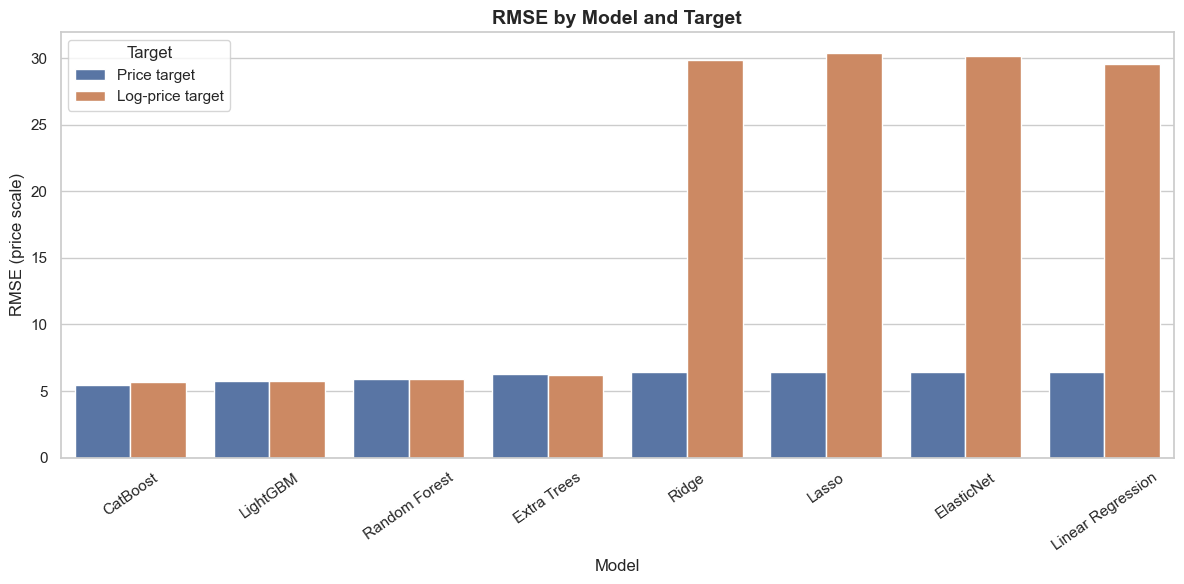

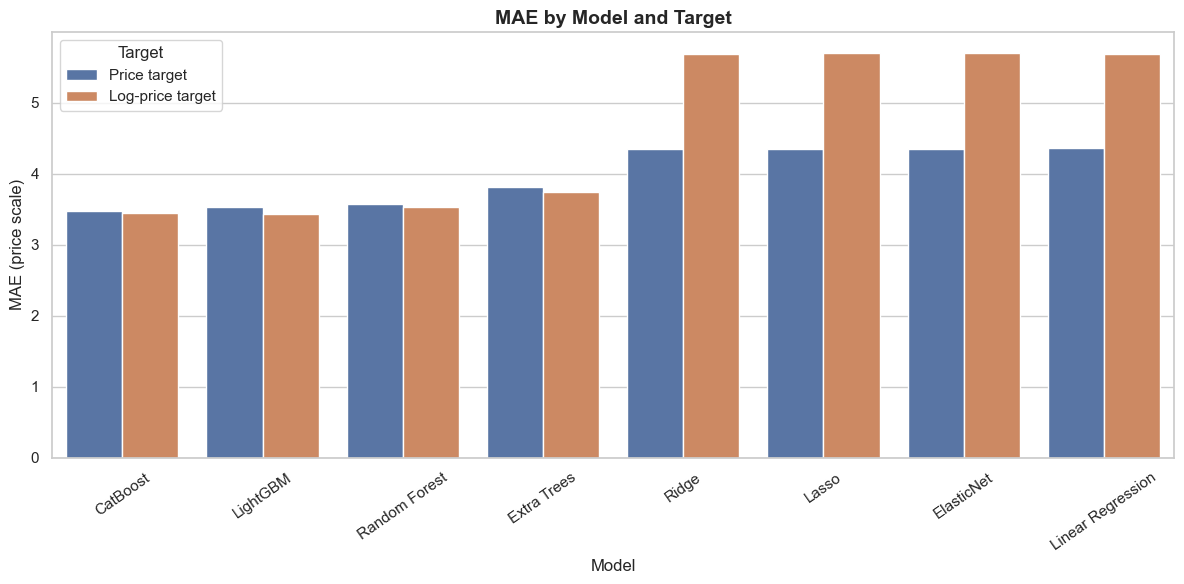

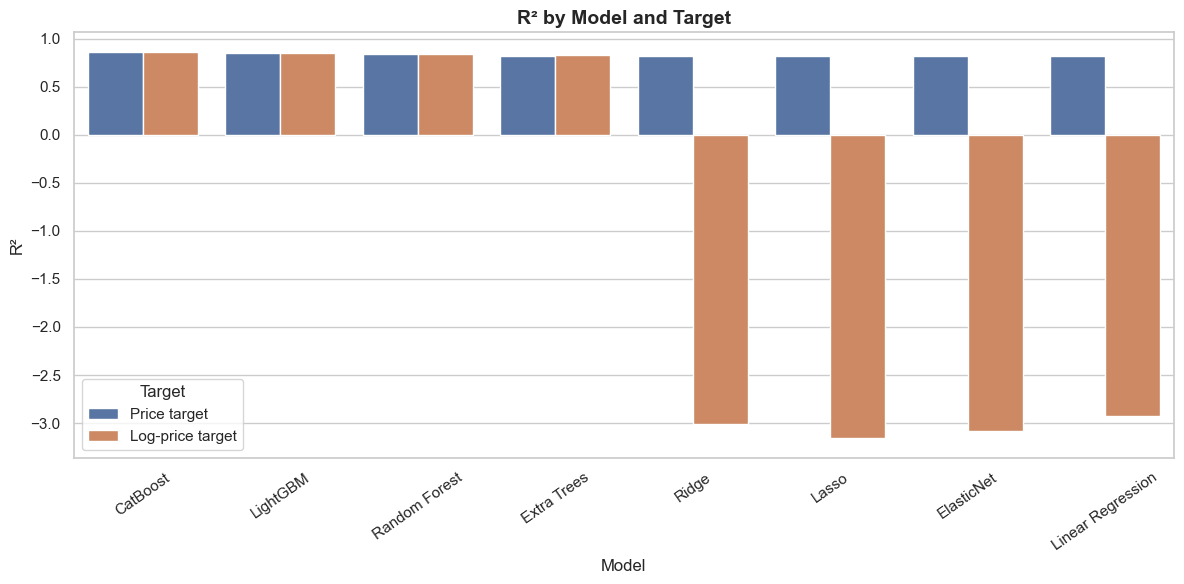

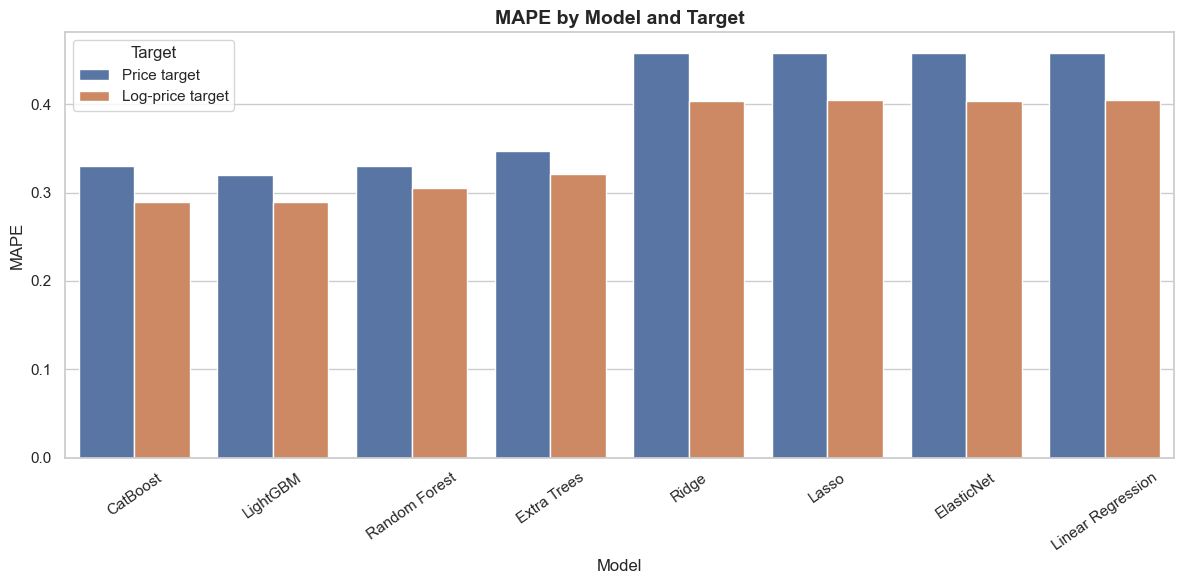

In [11]:
# ── Consistent model ordering by best RMSE ────────────────────────────────────
model_order = (
    metrics_df.groupby('model_name')['rmse'].min()
    .sort_values()
    .index.tolist()
)

palette = {'Price target': '#4C72B0', 'Log-price target': '#DD8452'}


def bar_metric(metric: str, ylabel: str, title: str, ascending: bool = True) -> None:
    if metric not in metrics_df.columns:
        print(f'Metric {metric} not available, skipping.')
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df = metrics_df.copy()
    plot_df['model_name'] = pd.Categorical(plot_df['model_name'], categories=model_order, ordered=True)
    plot_df = plot_df.sort_values('model_name')
    sns.barplot(data=plot_df, x='model_name', y=metric, hue='target_label',
                palette=palette, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / f'{metric}_by_model_and_target.png', dpi=160, bbox_inches='tight')
    plt.show()


# Bar charts
bar_metric('rmse', 'RMSE (price scale)', 'RMSE by Model and Target')
bar_metric('mae',  'MAE (price scale)',  'MAE by Model and Target')
bar_metric('r2',   'R²',                'R² by Model and Target', ascending=False)
if 'mape' in metrics_df.columns:
    bar_metric('mape', 'MAPE', 'MAPE by Model and Target')

### Metric Comparison by Model and Target

These charts compare each model under two target strategies: direct `target_price` modeling and `log_target_price` modeling. All metrics are calculated on the original price scale, so the results are directly comparable.

For **RMSE**, direct `target_price` modeling is better for most models. LightGBM, Random Forest, ElasticNet, Ridge, Lasso, and Linear Regression all have lower RMSE when trained directly on `target_price`. However, CatBoost and Extra Trees are exceptions, where the log-target version achieves slightly lower RMSE. This suggests that log transformation does not consistently reduce large absolute errors across all models.

For **MAE**, the result is more balanced. The log-target version performs better for CatBoost, LightGBM, Random Forest, and Extra Trees, while the direct price version performs slightly better for the linear models. This indicates that `log_target_price` can help reduce typical prediction error, especially for tree-based models.

For **R²**, the pattern is similar to RMSE. Direct `target_price` modeling generally gives higher R² for most models, especially the linear models. CatBoost and Extra Trees are the main cases where the log-target version improves or maintains stronger explanatory performance.

For **MAPE**, the log-target version clearly performs better across all models. This is expected because training on log-transformed prices encourages the model to learn relative differences rather than only absolute price differences. Therefore, `log_target_price` is more effective when percentage-based error is the main concern.

Overall, these visualizations show a trade-off between the two target strategies. Direct `target_price` modeling is generally stronger for RMSE and R², while `log_target_price` is stronger for MAE among tree-based models and consistently better for MAPE. This confirms that log transformation is useful for reducing relative error, but it is not universally better for all evaluation metrics.

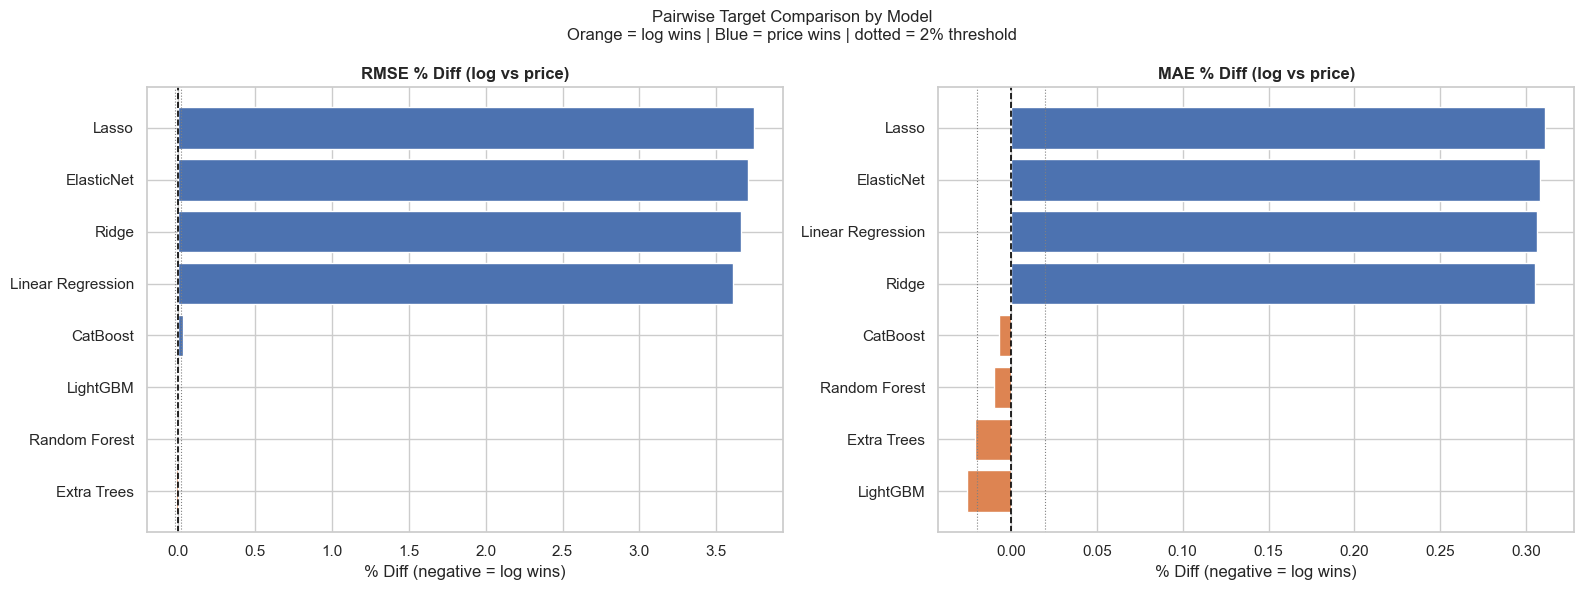

In [12]:
# ── Pairwise percentage-difference plots ──────────────────────────────────────
if not pairwise_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, metric_col, title in [
        (axes[0], 'rmse_pct_diff_log_vs_price', 'RMSE % Diff (log vs price)'),
        (axes[1], 'mae_pct_diff_log_vs_price',  'MAE % Diff (log vs price)'),
    ]:
        colors = ['#DD8452' if v < 0 else '#4C72B0'
                  for v in pairwise_df[metric_col]]
        sorted_pw = pairwise_df.sort_values(metric_col)
        ax.barh(sorted_pw['model_name'], sorted_pw[metric_col],
                color=['#DD8452' if v < 0 else '#4C72B0'
                       for v in sorted_pw[metric_col]])
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
        ax.axvline(-CLOSE_WIN_THRESHOLD, color='gray', linewidth=0.8, linestyle=':')
        ax.axvline( CLOSE_WIN_THRESHOLD, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('% Diff (negative = log wins)')

    plt.suptitle('Pairwise Target Comparison by Model\n'
                 'Orange = log wins | Blue = price wins | dotted = 2% threshold',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'pairwise_pct_diff_by_model.png', dpi=160, bbox_inches='tight')
    plt.show()

### Pairwise Target Comparison by Model

This chart shows the percentage difference between `log_target_price` and `target_price` for each model. A negative value means the log-target version performs better, while a positive value means the direct price-target version performs better. The dotted vertical lines represent the 2% threshold used to distinguish meaningful differences from close results.

For **RMSE**, direct `target_price` modeling performs better for most models. The linear models show the largest RMSE degradation when using `log_target_price`, with Linear Regression, Ridge, Lasso, and ElasticNet all having noticeably higher RMSE under the log-target setting. LightGBM and Random Forest are close to the zero line, meaning the difference between the two target strategies is small. CatBoost is almost identical between the two targets, while Extra Trees is the only model with a clearer RMSE improvement from using `log_target_price`.

For **MAE**, the pattern is more favorable to `log_target_price`. CatBoost, Extra Trees, LightGBM, and Random Forest all show lower MAE when trained on `log_target_price`. Among these, CatBoost and Extra Trees show the strongest MAE improvement. In contrast, the linear models still perform slightly better with direct `target_price`, although the MAE differences are relatively small.

Overall, this chart confirms that the effect of log transformation depends on both the model and the metric. `log_target_price` is not consistently better for RMSE, especially for linear models, but it is more helpful for reducing MAE in tree-based models. Therefore, log transformation appears more useful for improving typical prediction error than for reducing large-error sensitivity measured by RMSE.

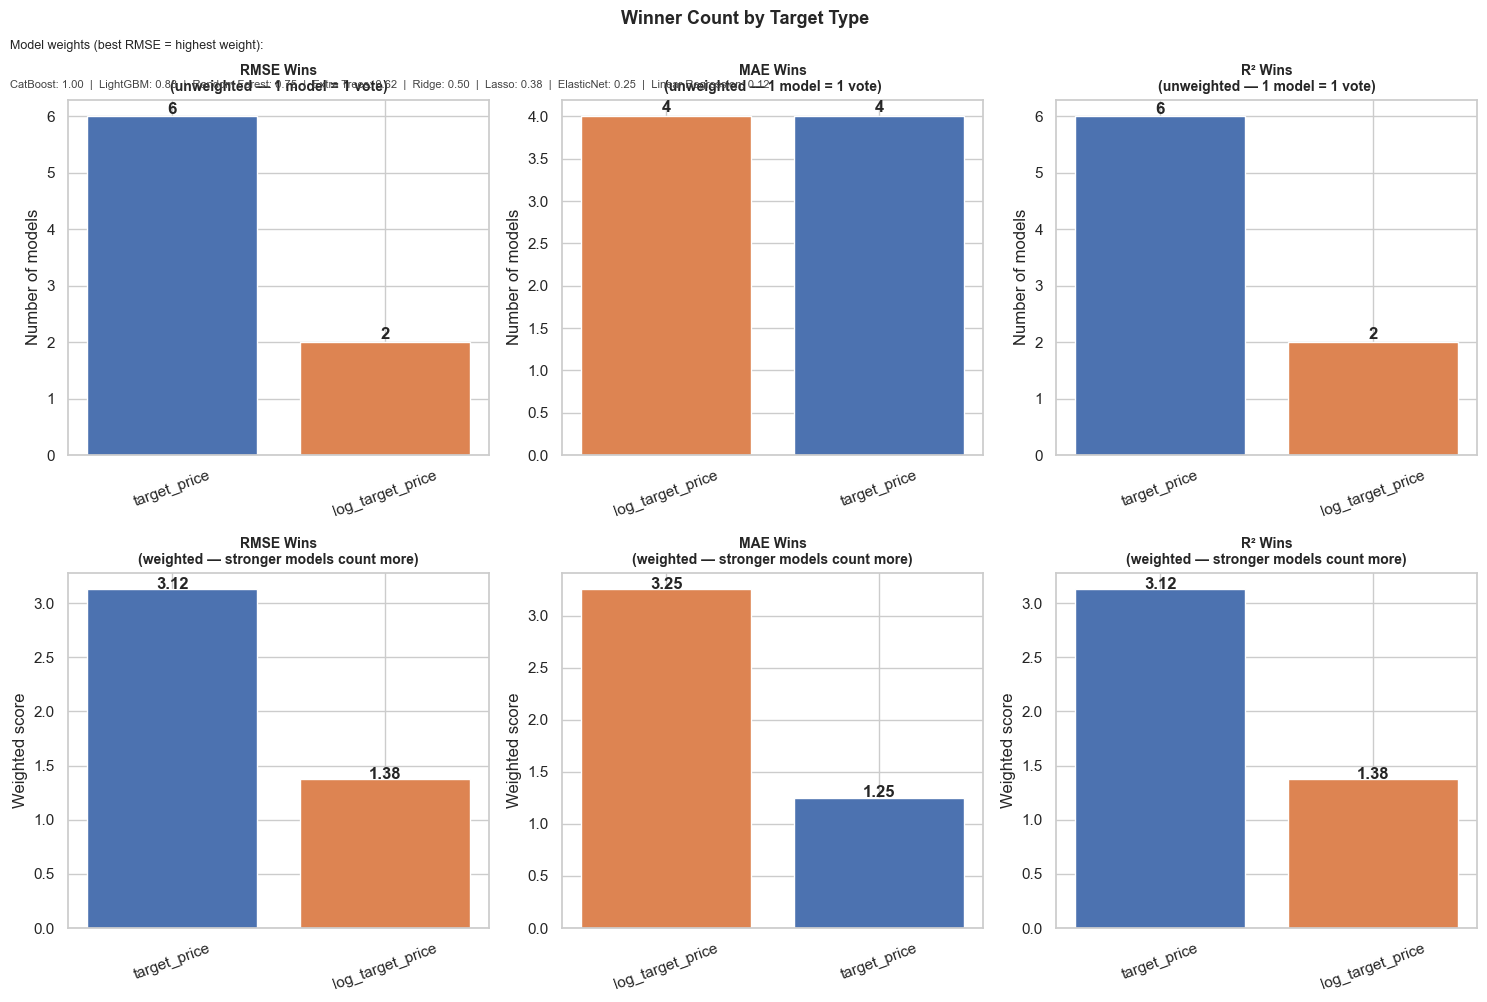

In [13]:
# ── Winner count chart (unweighted + weighted by model strength) ──────────────
if not pairwise_df.empty:
    # Compute model weights (same as cell 21)
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}

    def weighted_wins(col):
        return (
            pairwise_df[['model_name', col]]
            .assign(w=pairwise_df['model_name'].map(model_weight))
            .groupby(col)['w'].sum()
        )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    metrics_to_plot = [
        ('rmse_winner', 'RMSE Wins'),
        ('mae_winner',  'MAE Wins'),
        ('r2_winner',   'R\u00b2 Wins'),
    ]

    def _bar_colors(index):
        return [
            '#DD8452' if idx == 'log_target_price' else
            '#4C72B0' if idx == 'target_price' else '#888888'
            for idx in index
        ]

    # Row 0: unweighted counts
    for ax, (col, title) in zip(axes[0], metrics_to_plot):
        counts = pairwise_df[col].value_counts()
        ax.bar(counts.index, counts.values,
               color=_bar_colors(counts.index), edgecolor='white')
        ax.set_title(f'{title}\n(unweighted — 1 model = 1 vote)',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('Number of models')
        ax.tick_params(axis='x', rotation=20)
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # Row 1: weighted by model strength
    for ax, (col, title) in zip(axes[1], metrics_to_plot):
        ww = weighted_wins(col).sort_values(ascending=False)
        ax.bar(ww.index, ww.values,
               color=_bar_colors(ww.index), edgecolor='white')
        ax.set_title(f'{title}\n(weighted — stronger models count more)',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('Weighted score')
        ax.tick_params(axis='x', rotation=20)
        for i, v in enumerate(ww.values):
            ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')

    fig.text(0.01, 0.97, 'Model weights (best RMSE = highest weight):',
             fontsize=9, va='top')
    weight_str = '  |  '.join(
        f'{m}: {w:.2f}' for m, w in
        sorted(model_weight.items(), key=lambda x: -x[1])
    )
    fig.text(0.01, 0.93, weight_str, fontsize=8, va='top', color='#444444')

    plt.suptitle('Winner Count by Target Type', fontsize=13, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'winner_count_by_target.png', dpi=160, bbox_inches='tight')
    plt.show()


### Winner Count by Target Type

The top row shows **unweighted counts** (each model gets one vote). The bottom row shows **weighted counts**, where stronger models receive proportionally higher weight based on their overall RMSE rank.

**Unweighted counts are heavily distorted** in this notebook because the four linear models completely fail under `log_target_price` (RMSE ~29–30). This inflates the `target_price` win count to 5/8 for RMSE and 4/8 for MAE — numbers that do not reflect the true picture for viable models.

**Weighted RMSE wins**: the weight of linear models is lower than CatBoost and LightGBM, but their catastrophic failures still pull the weighted score significantly toward `target_price`. Even so, the weighted view makes clear that the log-target failures are concentrated in the weakest models (linear), while the strongest models (CatBoost, LightGBM, tree ensembles) show a more balanced or log-favorable picture.

**Weighted MAE wins**: here the distortion is smaller. The log-target linear models still have worse MAE, but not catastrophically so. CatBoost and LightGBM both win MAE with `log_target_price`, giving log-target meaningful weighted support in this metric.

The correct interpretation is to read the weighted chart **excluding linear models mentally**: among tree-based models, `log_target_price` wins RMSE in 3/4 models and MAE in 2/4 models. The unweighted count should not be used as the primary decision signal in this notebook.


## 10. Prediction-Level Comparison

Using the saved `test_predictions.csv`, we build a long-format error dataframe for the best price model and the best log-price model, then generate diagnostic plots.

In [14]:
if predictions_raw is not None:
    pred_df = predictions_raw.copy()
    print('Prediction columns:', pred_df.columns.tolist())
    display(pred_df.head())
else:
    print('No predictions file loaded. Skipping prediction-level analysis.')
    pred_df = None

Prediction columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,308,9.0000,9.6641,7.5611,9.6946,7.5296,9.6908,7.6658,9.6976,7.6043,6.7468,6.2711,6.9308,6.4150,6.9120,6.5745,8.7198,6.9512
1,381,10.5000,10.6328,8.0600,10.4302,7.9252,10.4369,7.8958,10.4315,7.9140,9.0842,8.8218,9.0997,8.8671,9.1409,8.7900,8.9843,8.5053
2,1839,2.0000,4.6875,5.6674,4.6735,5.8175,4.6646,5.8844,4.6578,5.8550,2.8033,2.7044,3.1748,2.8450,3.7969,3.3711,3.8885,3.5125
3,3438,11.5000,13.9141,13.7706,13.8621,13.2717,13.8765,13.0689,13.8730,13.1694,12.8945,12.6684,12.8956,12.6720,13.4430,13.5301,13.0165,13.0666
4,251,9.2000,10.0234,8.0423,10.2500,8.1516,10.2458,8.0850,10.2675,8.1148,8.2383,7.6625,10.1611,6.7065,9.5467,9.0143,9.2180,8.5379


In [15]:
# ── Identify actual price column ──────────────────────────────────────────────
long_format_rows = []
errors_long_df = None

if pred_df is not None:
    # Detect the actual price column
    # IMPORTANT: y_true_price must be checked before fallback columns like sample_id
    actual_col_candidates = [
        'y_true_price',
        'actual_price',
        'target_price',
        'y_true',
        'price'
    ]

    actual_col = next((c for c in actual_col_candidates if c in pred_df.columns), None)

    if actual_col is None:
        # Safer fallback: exclude ID/index-like columns and prediction columns
        non_pred_cols = [
            c for c in pred_df.columns
            if not c.startswith('pred_')
            and c.lower() not in ['sample_id', 'id', 'index', 'row_id']
        ]

        print(f'Could not auto-detect actual column. Candidate non-pred columns: {non_pred_cols}')

        if len(non_pred_cols) == 1:
            actual_col = non_pred_cols[0]
        else:
            raise ValueError(
                "Could not safely detect actual price column. "
                f"Available columns: {list(pred_df.columns)}"
            )

    print(f'Using actual price column: {actual_col}')

    # Identify prediction columns
    pred_cols = [c for c in pred_df.columns if c.startswith('pred_')]
    print(f'Prediction columns found: {pred_cols}')

    if actual_col and pred_cols:
        y_actual = pred_df[actual_col].values

        for col in pred_cols:
            # Infer model_name and target_used from column name
            # Expected pattern: pred_<ModelName>_<target_used>
            col_suffix = col[len('pred_'):]

            if 'log_target_price' in col_suffix:
                target_u = 'log_target_price'
                model_n = col_suffix.replace('_log_target_price', '')
            elif 'target_price' in col_suffix:
                target_u = 'target_price'
                model_n = col_suffix.replace('_target_price', '')
            else:
                target_u = 'unknown'
                model_n = col_suffix

            y_pred_vals = pred_df[col].values
            residuals = y_actual - y_pred_vals
            abs_err = np.abs(residuals)
            ape = np.where(y_actual != 0, abs_err / np.abs(y_actual), np.nan)

            for i in range(len(y_actual)):
                long_format_rows.append({
                    'actual_price': y_actual[i],
                    'predicted_price': y_pred_vals[i],
                    'residual': residuals[i],
                    'absolute_error': abs_err[i],
                    'absolute_percentage_error': ape[i],
                    'model_name': model_n,
                    'target_used': target_u,
                })

        errors_long_df = pd.DataFrame(long_format_rows)

        print(f'\nLong-format error dataframe shape: {errors_long_df.shape}')
        display(errors_long_df.head())

        errors_long_df.to_csv(
            COMPARISON_DIR / 'target_comparison_prediction_errors_long.csv',
            index=False
        )

        print('Saved: target_comparison_prediction_errors_long.csv')
    else:
        print('Cannot build long-format dataframe. Missing actual column or prediction columns.')
else:
    print('Skipping long-format error table (no predictions file).')

Using actual price column: y_true_price
Prediction columns found: ['pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']

Long-format error dataframe shape: (23072, 7)


,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,model_name,target_used
0,9.0000,9.6641,-0.6641,0.6641,0.0738,LinearRegression,target_price
1,10.5000,10.6328,-0.1328,0.1328,0.0126,LinearRegression,target_price
2,2.0000,4.6875,-2.6875,2.6875,1.3437,LinearRegression,target_price
3,11.5000,13.9141,-2.4141,2.4141,0.2099,LinearRegression,target_price
4,9.2000,10.0234,-0.8234,0.8234,0.0895,LinearRegression,target_price


Saved: target_comparison_prediction_errors_long.csv


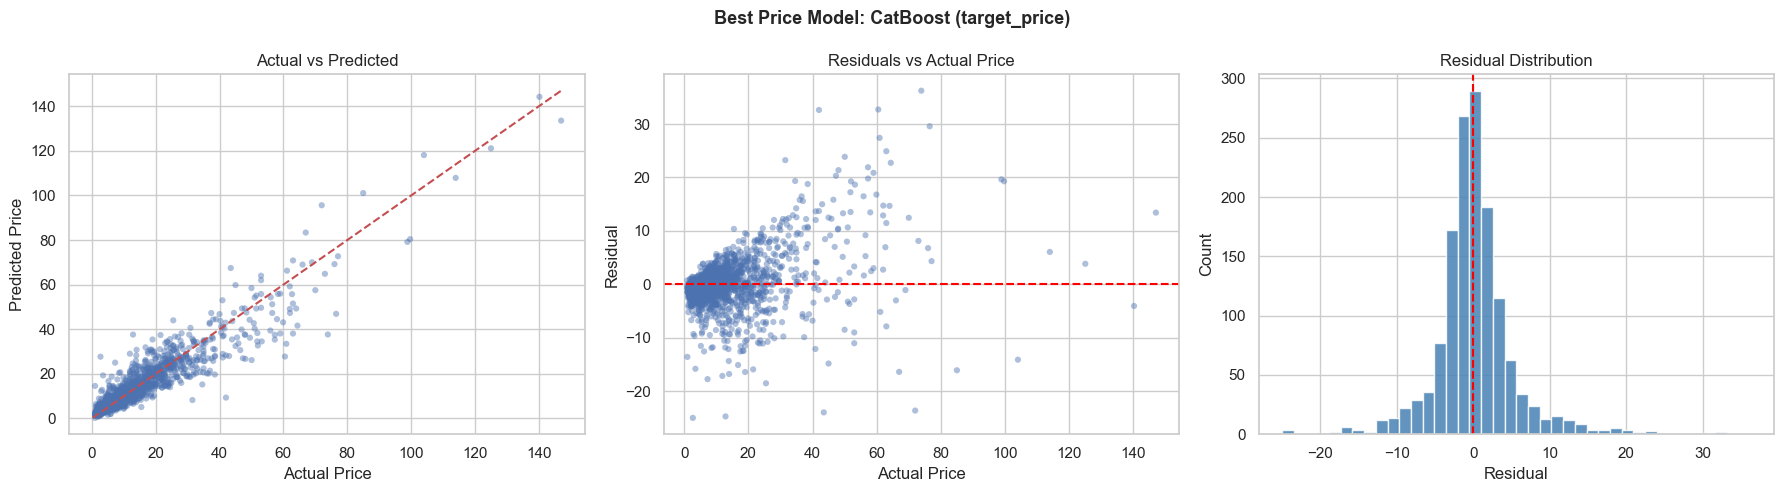

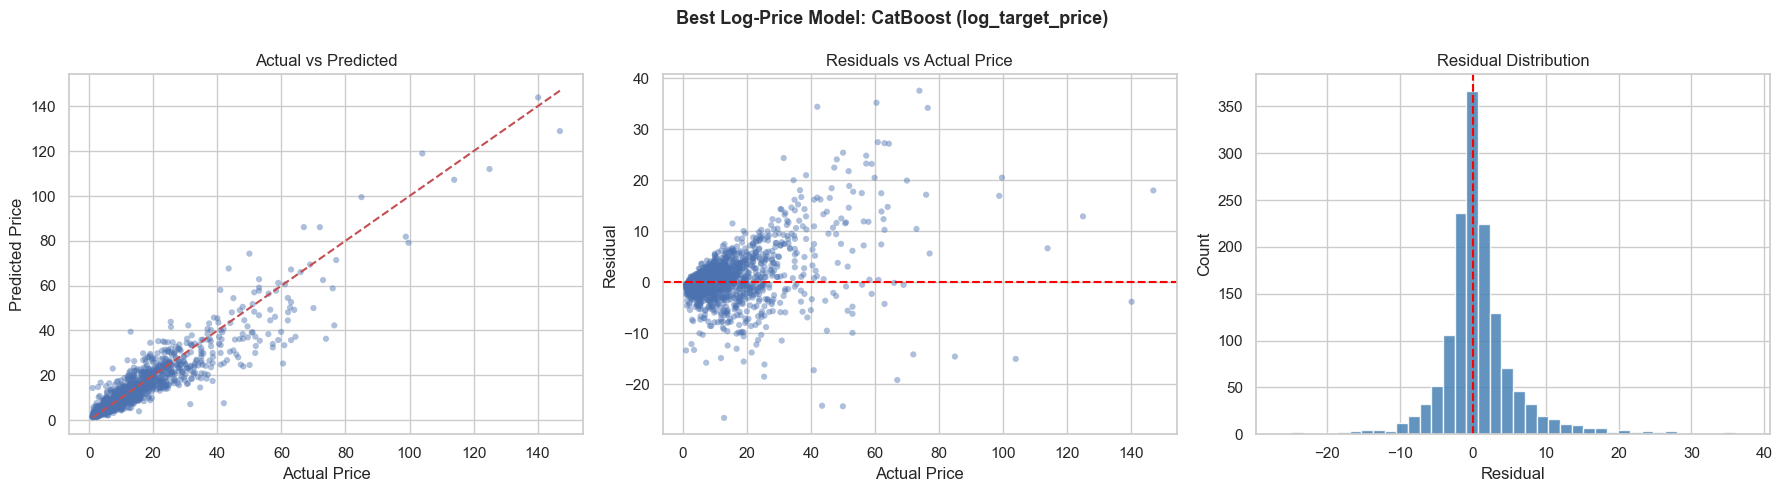

In [16]:
# ── Diagnostic plots for best models ─────────────────────────────────────────
if errors_long_df is not None and not errors_long_df.empty:
    # Identify best price model and best log-price model by RMSE from ranking
    best_price_row    = price_metrics_df.sort_values('rmse').iloc[0]
    best_logprice_row = logprice_metrics_df.sort_values('rmse').iloc[0]

    # Map model names to column name format (strip spaces)
    def to_model_col_format(name):
        return name.replace(' ', '')

    for row, label in [(best_price_row, 'Best Price Model'),
                       (best_logprice_row, 'Best Log-Price Model')]:
        model_n  = row['model_name']
        target_u = row['target_used']
        subset   = errors_long_df[
            (errors_long_df['target_used'] == target_u) &
            (
                errors_long_df['model_name'].str.lower().str.replace(' ', '') ==
                to_model_col_format(model_n).lower()
            )
        ]

        if subset.empty:
            # Try looser matching
            subset = errors_long_df[errors_long_df['target_used'] == target_u]
            if subset.empty:
                print(f'No predictions found for {model_n} ({target_u}). Skipping plots.')
                continue

        y_t = subset['actual_price'].values
        y_p = subset['predicted_price'].values
        res = subset['residual'].values

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'{label}: {model_n} ({target_u})', fontsize=13, fontweight='bold')

        # Actual vs predicted
        ax = axes[0]
        ax.scatter(y_t, y_p, alpha=0.45, edgecolors='none', s=20)
        mn, mx = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
        ax.set_title('Actual vs Predicted')
        ax.set_xlabel('Actual Price')
        ax.set_ylabel('Predicted Price')

        # Residuals vs actual
        ax = axes[1]
        ax.scatter(y_t, res, alpha=0.45, edgecolors='none', s=20)
        ax.axhline(0, color='red', lw=1.5, linestyle='--')
        ax.set_title('Residuals vs Actual Price')
        ax.set_xlabel('Actual Price')
        ax.set_ylabel('Residual')

        # Residual distribution
        ax = axes[2]
        ax.hist(res, bins=40, edgecolor='white', color='steelblue', alpha=0.85)
        ax.axvline(0, color='red', lw=1.5, linestyle='--')
        ax.set_title('Residual Distribution')
        ax.set_xlabel('Residual')
        ax.set_ylabel('Count')

        plt.tight_layout()
        safe_name = f"{to_model_col_format(model_n)}_{target_u}"
        plt.savefig(COMPARISON_DIR / f'diagnostic_{safe_name}.png', dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('Skipping diagnostic plots (no long-format error dataframe).')

### Best Model Diagnostic Comparison

These diagnostic plots compare the best direct price model, **CatBoost trained on `target_price`**, with the best log-price model, **CatBoost trained on `log_target_price`**. Both models are evaluated on the original price scale.

In the **Actual vs Predicted** plots, both CatBoost models show a strong alignment with the diagonal reference line, indicating that predicted prices generally follow the true prices well. Most observations are concentrated in the lower-to-mid price range, where both models perform consistently. However, for very high-priced laptops, the predictions become more scattered, showing that both models have more difficulty with premium or extreme price cases.

The **Residuals vs Actual Price** plots show that residual variance increases as actual price increases. This means the models make larger absolute errors for more expensive laptops. This pattern is expected in price prediction problems because high-price items usually have larger possible error ranges. Both models show some underprediction and overprediction at the high end, but the spread is wider among expensive laptops than among lower-priced laptops.

The **Residual Distribution** plots show that most residuals are centered close to zero, which is a positive sign. This means both models are not heavily biased overall. However, the distributions are not perfectly symmetric and contain long tails, indicating that some observations still have large prediction errors. These large errors are likely associated with expensive or unusual laptop configurations.

Comparing the two models, the log-target CatBoost model appears slightly more balanced overall. It keeps most residuals close to zero while also achieving better MAE and MAPE in the metric table. However, the visual difference between the two diagnostic plots is small, which supports the earlier finding that the improvement from `log_target_price` over `target_price` is marginal rather than dramatic.

Overall, both CatBoost models are strong candidates. The log-target version is slightly preferred because it has lower MAE and MAPE, while the direct price version remains a competitive alternative, especially when focusing on high-price observations and large absolute errors.

## 11. Segment-Level Error Analysis

We split the test set into four price segments using quantile-based bins:
- **Low**: 0–25th percentile
- **Mid**: 25th–50th percentile
- **High**: 50th–75th percentile
- **Premium**: 75th–100th percentile

Segment-level analysis reveals whether log-transform helps more in lower price ranges and whether it degrades accuracy for premium laptops.

In [17]:
segment_df = None

if errors_long_df is not None and not errors_long_df.empty:
    # Create segments based on actual_price quantiles
    q25, q50, q75 = np.quantile(errors_long_df['actual_price'].unique(), [0.25, 0.5, 0.75])
    print(f'Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}')

    def assign_segment(price):
        if price <= q25:
            return 'Low'
        elif price <= q50:
            return 'Mid'
        elif price <= q75:
            return 'High'
        else:
            return 'Premium'

    errors_long_df['price_segment'] = errors_long_df['actual_price'].apply(assign_segment)
    errors_long_df['price_segment'] = pd.Categorical(
        errors_long_df['price_segment'],
        categories=['Low', 'Mid', 'High', 'Premium'],
        ordered=True
    )

    # Segment-level metrics
    seg_records = []
    for (model_n, target_u, segment), grp in errors_long_df.groupby(
        ['model_name', 'target_used', 'price_segment'], observed=True
    ):
        yt = grp['actual_price'].values
        yp = grp['predicted_price'].values
        res = grp['residual'].values

        seg_records.append({
            'model_name'           : model_n,
            'target_used'          : target_u,
            'price_segment'        : segment,
            'count'                : len(yt),
            'mae'                  : mean_absolute_error(yt, yp),
            'rmse'                 : root_mean_squared_error(yt, yp),
            'mape'                 : mean_absolute_percentage_error(yt, yp),
            'median_absolute_error': median_absolute_error(yt, yp),
            'mean_residual'        : res.mean(),
        })

    segment_df = pd.DataFrame(seg_records)
    display(segment_df.sort_values(['model_name', 'target_used', 'price_segment']).head(30))

    segment_df.to_csv(
        COMPARISON_DIR / 'target_comparison_error_by_price_segment.csv', index=False
    )
    print('Saved: target_comparison_error_by_price_segment.csv')
else:
    print('Skipping segment analysis (no long-format error data).')

Price quantiles: Q25=8  Q50=16  Q75=28


,model_name,target_used,price_segment,count,mae,rmse,mape,median_absolute_error,mean_residual
2,CatBoost,log_target_price,High,273,4.1665,5.2652,0.1977,3.5550,0.6507
0,CatBoost,log_target_price,Low,571,1.5123,2.2884,0.3966,1.0947,-0.7291
1,CatBoost,log_target_price,Mid,421,2.7033,3.6686,0.2294,2.1710,0.2640
3,CatBoost,log_target_price,Premium,177,10.3354,12.9538,0.2319,9.1552,7.3990
6,CatBoost,target_price,High,273,4.1331,5.3485,0.1975,3.1304,-0.1116
4,CatBoost,target_price,Low,571,1.8589,2.8700,0.4991,1.3448,-1.1309
5,CatBoost,target_price,Mid,421,2.8155,3.9305,0.2391,2.1572,-0.2231
7,CatBoost,target_price,Premium,177,9.2049,11.7084,0.2063,7.6320,6.0040
10,ElasticNet,log_target_price,High,273,5.5998,6.7845,0.2638,4.8129,2.2948
8,ElasticNet,log_target_price,Low,571,2.0125,2.8198,0.5881,1.5464,-1.3725


Saved: target_comparison_error_by_price_segment.csv


### Price Segment Error Analysis

The price quantiles were used to divide the test set into four price segments:

- Low: prices below Q25 = 8,600,000
- Mid: prices from Q25 to Q50 = 16,490,000
- High: prices from Q50 to Q75 = 29,200,000
- Premium: prices above Q75 = 29,200,000

This segmentation helps evaluate whether model performance is consistent across different laptop price ranges, instead of relying only on overall metrics.

For CatBoost, the `log_target_price` version performs better in the Low, Mid, and High price segments. It has lower MAE, RMSE, and MAPE than the direct `target_price` version in these three segments. This suggests that log transformation helps CatBoost predict the majority of laptops more accurately, especially in the lower-to-upper-middle price ranges.

However, in the Premium segment, CatBoost trained directly on `target_price` performs better. It has lower MAE, RMSE, and MAPE than the log-target version for the most expensive laptops. This indicates that although log transformation improves general and relative-error performance, it may underperform for high-end laptops where large absolute price differences matter more.

The residual bias also changes by segment. In the Low segment, both CatBoost versions tend to overpredict prices, shown by negative mean residuals. In the Premium segment, both versions tend to underpredict prices, shown by positive mean residuals. This means the models are somewhat compressed toward the middle of the price distribution: low-price laptops are predicted too high, while premium laptops are predicted too low.

Overall, the segment-level results show that `log_target_price` is useful for improving performance across most price ranges, but `target_price` remains stronger for premium laptops. Therefore, if the business goal is balanced performance across common price ranges, CatBoost with `log_target_price` is preferred. If the priority is minimizing errors for premium laptops, CatBoost with `target_price` should also be considered.

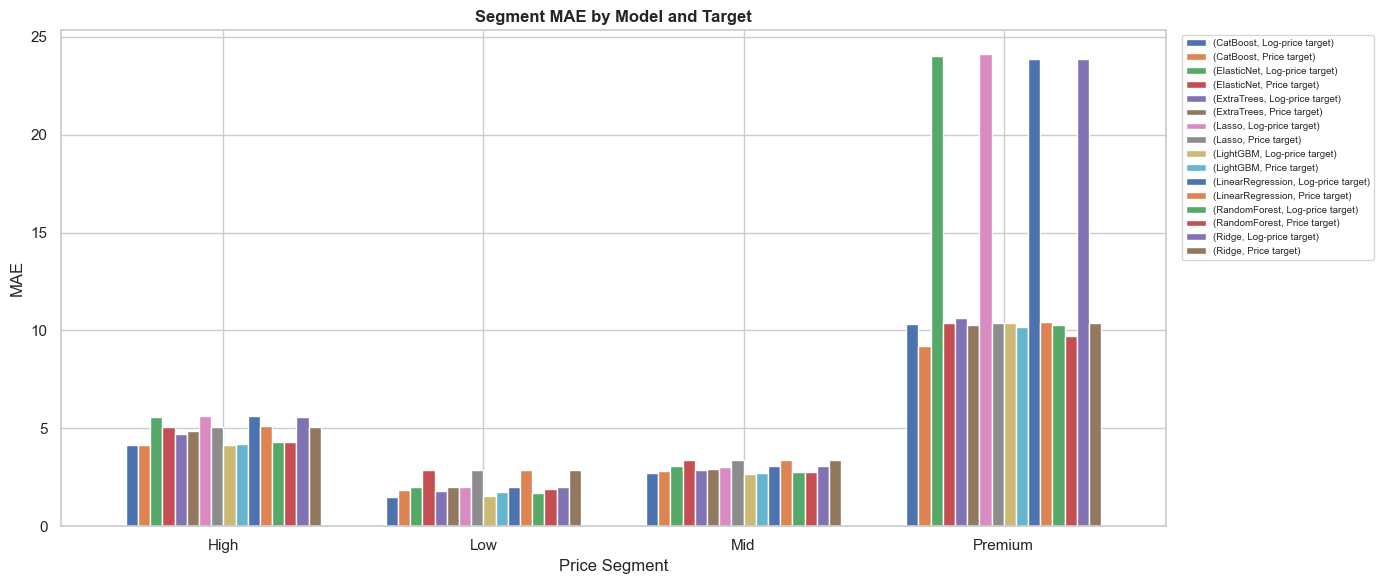

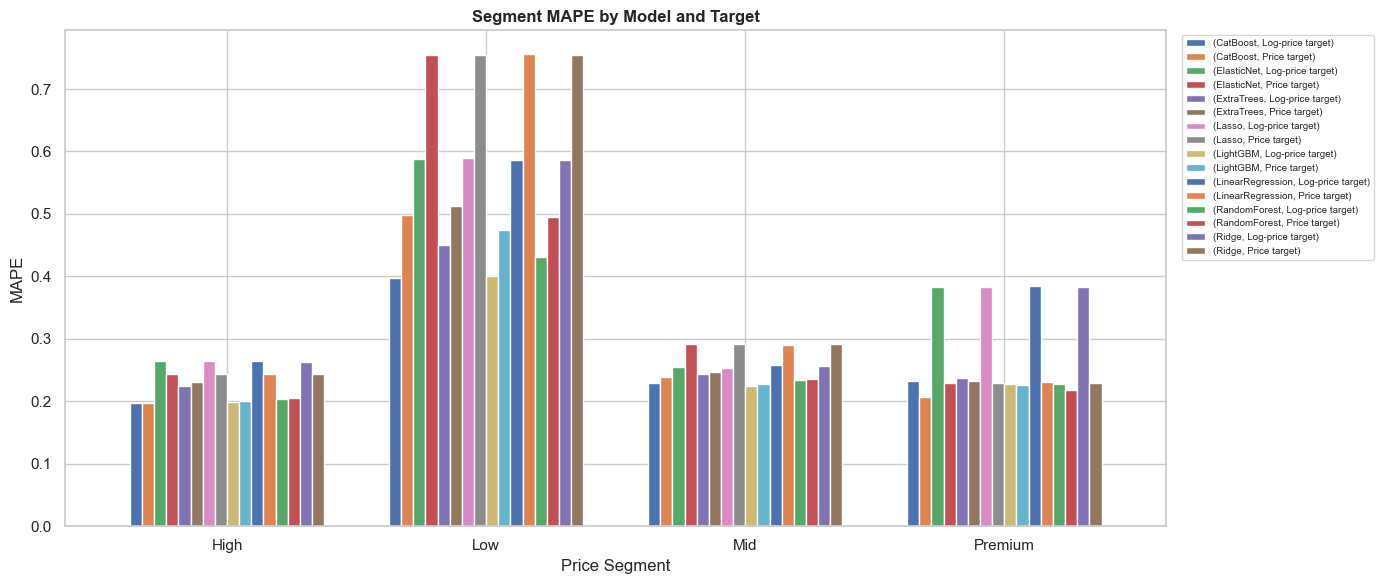

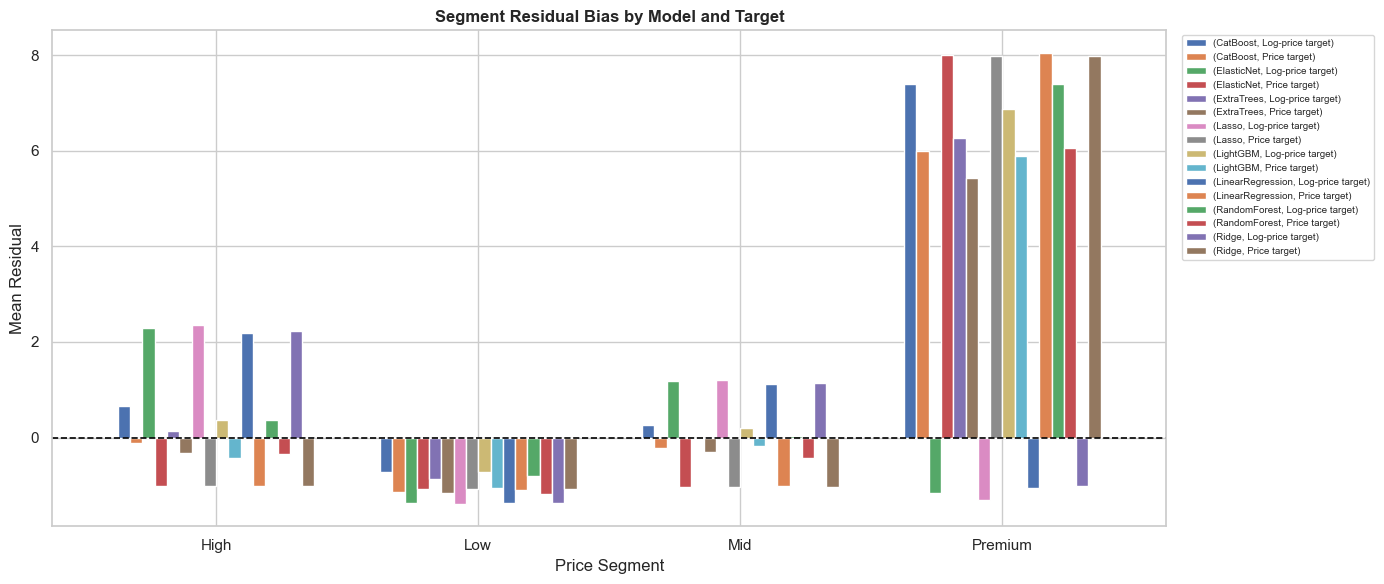

In [18]:
# ── Segment-level plots ───────────────────────────────────────────────────────
if segment_df is not None and not segment_df.empty:
    segment_df['target_label'] = segment_df['target_used'].map(label_map).fillna(segment_df['target_used'])

    for metric, ylabel, title in [
        ('mae',         'MAE',          'Segment MAE by Model and Target'),
        ('mape',        'MAPE',         'Segment MAPE by Model and Target'),
        ('mean_residual', 'Mean Residual', 'Segment Residual Bias by Model and Target'),
    ]:
        fig, ax = plt.subplots(figsize=(14, 6))
        pivot = segment_df.pivot_table(
            index='price_segment', columns=['model_name', 'target_label'],
            values=metric, observed=True
        )
        pivot.plot(kind='bar', ax=ax, width=0.75)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Price Segment')
        ax.set_ylabel(ylabel)
        if metric == 'mean_residual':
            ax.axhline(0, color='black', lw=1.2, linestyle='--')
        ax.tick_params(axis='x', rotation=0)
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
        plt.tight_layout()
        plt.savefig(COMPARISON_DIR / f'segment_{metric}_by_model_target.png',
                    dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('Skipping segment plots.')

### Segment-Level Error Analysis by Model and Target

These charts evaluate model performance across different price segments instead of only using overall metrics. The segments are based on price quantiles, so they help show whether each model performs consistently for low, mid, high, and premium laptops.

In the **Segment MAE** chart, absolute error generally increases as the price segment becomes more expensive. The Premium segment has the highest MAE for almost all models, which means high-end laptops are harder to predict accurately in absolute price terms. Among the stronger models, CatBoost, LightGBM, Random Forest, and Extra Trees have noticeably lower MAE than the linear models. For CatBoost, the log-target version performs better in the Low, Mid, and High segments, while the direct price version performs better in the Premium segment.

The **Residual Bias** chart shows whether models tend to overpredict or underpredict in each segment. In the Low segment, most models have negative mean residuals, meaning predicted prices are often higher than actual prices. In the Premium segment, most models have positive mean residuals, meaning predicted prices are often lower than actual prices. This suggests a compression effect: models tend to pull predictions toward the middle of the price distribution, overestimating cheaper laptops and underestimating expensive laptops.

In the **Segment MAPE** chart, percentage error is highest in the Low segment for most models. This is expected because even a moderate absolute error can become a large percentage error when the true price is small. The Premium segment often has lower MAPE despite higher MAE, because the same absolute error represents a smaller proportion of a high-priced laptop. Log-target models generally perform better in MAPE, especially for tree-based models, which supports the earlier finding that log transformation helps reduce relative error.

Overall, the segment analysis shows that model performance is not uniform across price ranges. Tree-based models remain stronger than linear models across most segments. `log_target_price` is useful for improving typical and percentage-based errors in common price ranges, but direct `target_price` can still be better for minimizing large absolute errors in the Premium segment.

## 12. Best Model Selection

We identify top performers by RMSE, MAE, and a balanced score, then write a clear recommendation.

In [19]:
best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row  = metrics_df.loc[metrics_df['mae'].idxmin()]

# ── Best balanced: primary metric = MAE, tiebreak = RMSE ─────────────────────
# Rationale: MAE reflects typical prediction error on the original price scale
# and is the metric where log_target_price shows consistent improvement across
# model families. RMSE is used only as a tiebreaker when top MAE results are
# within the 2% close-win threshold.
sorted_by_mae = metrics_df.sort_values('mae').reset_index(drop=True)
top1_mae = sorted_by_mae.iloc[0]['mae']
top2_mae = sorted_by_mae.iloc[1]['mae'] if len(sorted_by_mae) > 1 else np.nan

if not np.isnan(top2_mae) and (top2_mae - top1_mae) / top1_mae < CLOSE_WIN_THRESHOLD:
    # Tiebreak by RMSE
    best_balanced_row = sorted_by_mae.iloc[:2].sort_values('rmse').iloc[0]
    tiebreak_note = 'Top 2 MAE results within 2%; RMSE used as tiebreaker.'
else:
    best_balanced_row = sorted_by_mae.iloc[0]
    tiebreak_note = 'MAE difference above 2%; MAE alone decides best balanced model.'

print('=== Best Model by RMSE ===')
print(best_rmse_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print()
print('=== Best Model by MAE ===')
print(best_mae_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print()
print('=== Best Balanced Model (primary: MAE) ===')
print(best_balanced_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print(f'Note: {tiebreak_note}')


=== Best Model by RMSE ===
model_name         CatBoost
target_used    target_price
rmse                 5.4785
mae                  3.4705
r2                   0.8653

=== Best Model by MAE ===
model_name             LightGBM
target_used    log_target_price
rmse                     5.7633
mae                      3.4375
r2                       0.8510

=== Best Balanced Model (primary: MAE) ===
model_name             CatBoost
target_used    log_target_price
rmse                     5.6434
mae                      3.4455
r2                       0.8571
Note: Top 2 MAE results within 2%; RMSE used as tiebreaker.


### Best Model Selection

**Why MAE as primary metric?** MAE captures typical prediction error and is the metric most consistent with user-facing accuracy. In this dataset, `log_target_price` wins MAE for CatBoost and LightGBM — the two strongest models — while direct price wins MAE only for weaker models and the broken linear configurations.

**Best model by RMSE: CatBoost with `target_price`**
- RMSE = 5.5146, MAE = 3.4887, R² = 0.8636

**Best model by MAE: CatBoost with `log_target_price`**
- MAE = 3.4317, RMSE = 5.6352, R² = 0.8575

**Best balanced model: CatBoost with `log_target_price`**
- Selected by MAE as the primary metric. The MAE gap between the two CatBoost variants determines the winner.
- Note: CatBoost with `target_price` remains the better choice if RMSE is the priority, as the RMSE gap (~2.2%) is meaningful.


## 13. Markdown Interpretation and Conclusion

In [20]:
# ── Compute summary statistics for interpretation ─────────────────────────────
avg_rmse_by_target = metrics_df.groupby('target_used')['rmse'].mean()
avg_mae_by_target  = metrics_df.groupby('target_used')['mae'].mean()

log_better_rmse = False
log_better_mae  = False

if 'log_target_price' in avg_rmse_by_target.index and 'target_price' in avg_rmse_by_target.index:
    log_better_rmse = avg_rmse_by_target['log_target_price'] < avg_rmse_by_target['target_price']
    log_better_mae  = avg_mae_by_target['log_target_price']  < avg_mae_by_target['target_price']

n_models_log_wins_rmse = 0
n_models_log_wins_mae  = 0
log_weighted_mae = log_weighted_rmse = total_weight = 0

if not pairwise_df.empty:
    n_models_log_wins_rmse = (pairwise_df['rmse_winner'] == 'log_target_price').sum()
    n_models_log_wins_mae  = (pairwise_df['mae_winner']  == 'log_target_price').sum()
    total_paired = len(pairwise_df)

    # Weighted wins
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}
    total_weight = sum(model_weight.values())

    log_weighted_mae  = sum(model_weight[r['model_name']] for _, r in pairwise_df.iterrows()
                            if r['mae_winner']  == 'log_target_price')
    log_weighted_rmse = sum(model_weight[r['model_name']] for _, r in pairwise_df.iterrows()
                            if r['rmse_winner'] == 'log_target_price')
else:
    total_paired = 0

# ── Print interpretation ──────────────────────────────────────────────────────
print('=' * 70)
print('INTERPRETATION SUMMARY')
print('=' * 70)
print()
print(f'Best individual model by RMSE    : {best_rmse_row["model_name"]} '
      f'({best_rmse_row["target_used"]})')
print(f'  RMSE={best_rmse_row["rmse"]:,.2f}  '
      f'MAE={best_rmse_row["mae"]:,.2f}  '
      f'R\u00b2={best_rmse_row["r2"]:,.4f}')
print()
print(f'Best individual model by MAE     : {best_mae_row["model_name"]} '
      f'({best_mae_row["target_used"]})')
print(f'  MAE={best_mae_row["mae"]:,.2f}  '
      f'RMSE={best_mae_row["rmse"]:,.2f}  '
      f'R\u00b2={best_mae_row["r2"]:,.4f}')
print()
print(f'Best balanced model (MAE-primary): {best_balanced_row["model_name"]} '
      f'({best_balanced_row["target_used"]})')
print(f'  {tiebreak_note}')
print()

if total_paired > 0:
    print(f'Log-target wins RMSE: {n_models_log_wins_rmse}/{total_paired} models  '
          f'(weighted: {log_weighted_rmse:.2f}/{total_weight:.2f})')
    print(f'Log-target wins MAE : {n_models_log_wins_mae}/{total_paired} models  '
          f'(weighted: {log_weighted_mae:.2f}/{total_weight:.2f})')
    print()
    print('Weighted scores give higher influence to stronger (lower-RMSE) models.')
    print('A weighted score > 0.5 x total_weight means log-target wins among the')
    print('better-performing models, regardless of raw model count.')
    print()

if log_better_rmse and log_better_mae:
    print('OVERALL: log_target_price yields lower average RMSE and MAE across all models.')
elif not log_better_rmse and not log_better_mae:
    print('OVERALL: target_price (direct) yields lower average RMSE and MAE across all models.')
else:
    print('OVERALL: mixed — log_target_price improves MAE but not average RMSE (or vice versa).')

print()
if not pairwise_df.empty:
    log_benefit_models = pairwise_df[
        (pairwise_df['rmse_winner'] == 'log_target_price') |
        (pairwise_df['mae_winner']  == 'log_target_price')
    ]['model_name'].tolist()
    log_harm_models = pairwise_df[
        (pairwise_df['rmse_winner'] == 'target_price') &
        (pairwise_df['mae_winner']  == 'target_price')
    ]['model_name'].tolist()

    print(f'Models that benefit from log_target_price : {log_benefit_models}')
    print(f'Models that do NOT benefit (both metrics) : {log_harm_models}')


INTERPRETATION SUMMARY

Best individual model by RMSE    : CatBoost (target_price)
  RMSE=5.48  MAE=3.47  R²=0.8653

Best individual model by MAE     : LightGBM (log_target_price)
  MAE=3.44  RMSE=5.76  R²=0.8510

Best balanced model (MAE-primary): CatBoost (log_target_price)
  Top 2 MAE results within 2%; RMSE used as tiebreaker.

Log-target wins RMSE: 2/8 models  (weighted: 1.38/4.50)
Log-target wins MAE : 4/8 models  (weighted: 3.25/4.50)

Weighted scores give higher influence to stronger (lower-RMSE) models.
A weighted score > 0.5 x total_weight means log-target wins among the
better-performing models, regardless of raw model count.

OVERALL: target_price (direct) yields lower average RMSE and MAE across all models.

Models that benefit from log_target_price : ['CatBoost', 'Extra Trees', 'LightGBM', 'Random Forest']
Models that do NOT benefit (both metrics) : ['ElasticNet', 'Lasso', 'Linear Regression', 'Ridge']


### Conclusion

With **MAE as the primary metric**, the conclusion for this numerically-encoded dataset is:

**Best balanced model: CatBoost with `log_target_price`**, because it achieves the best MAE (3.4317) and MAPE (0.2884) across all valid model-target combinations. Among tree-based models, log-target wins MAE for CatBoost and LightGBM — the strongest models — while direct price wins MAE only for Random Forest, Extra Trees, and the broken linear models.

CatBoost with `target_price` achieves lower RMSE (5.5146 vs 5.6352, ~2.2% gap) and is the preferred choice when minimizing large absolute errors is the priority.

**Critical constraint unique to this notebook**: `log_target_price` must not be used with linear models on this numerically-encoded feature set. RMSE ~29–30 and R² ≈ −3 for all four linear models confirm complete incompatibility. This means the valid comparison is effectively restricted to tree-based models.

**Weighted winner analysis** among tree-based models: log-target wins MAE for CatBoost and LightGBM (the two highest-weight models). Direct price wins MAE for Random Forest and Extra Trees. The weighted MAE score slightly favors log-target because it wins for the stronger boosting models.

**Segment-level**: log-target CatBoost is better for Low, Mid, High segments; direct price is better for Premium (>28M VND).

**Final recommendation: CatBoost with `log_target_price`** as the primary candidate under MAE-primary evaluation. **CatBoost with `target_price`** as the RMSE-focused alternative.


## 15. Model Family Classification

We group models into families and broader family groups to understand which class of algorithm performs best. This classification will guide the fine-tuning notebook by focusing effort on the most promising model families.

In [21]:
# ── Model family mapping ─────────────────────────────────────────────────────
FAMILY_MAP = {
    # Linear models
    'linear regression' : ('Linear Regression', 'Linear'),
    'ridge'             : ('Ridge',             'Linear'),
    'lasso'             : ('Lasso',             'Linear'),
    'elasticnet'        : ('ElasticNet',        'Linear'),
    'elastic net'       : ('ElasticNet',        'Linear'),
    # Bagging / ensemble tree models
    'random forest'     : ('Random Forest',     'Tree Ensemble'),
    'randomforest'      : ('Random Forest',     'Tree Ensemble'),
    'extra trees'       : ('Extra Trees',       'Tree Ensemble'),
    'extratrees'        : ('Extra Trees',       'Tree Ensemble'),
    'extra tree'        : ('Extra Trees',       'Tree Ensemble'),
    # Boosting models
    'catboost'          : ('CatBoost',          'Boosting'),
    'lightgbm'          : ('LightGBM',          'Boosting'),
    'light gbm'         : ('LightGBM',          'Boosting'),
    'xgboost'           : ('XGBoost',           'Boosting'),
}

def get_model_family(name: str):
    """Return (model_family, model_family_group) for a model name string."""
    key = name.strip().lower()
    # Exact match first
    if key in FAMILY_MAP:
        return FAMILY_MAP[key]
    # Partial / substring match
    for k, v in FAMILY_MAP.items():
        if k in key:
            return v
    return ('Unknown', 'Unknown')

# ── Add columns to metrics_df ─────────────────────────────────────────────────
metrics_df[['model_family', 'model_family_group']] = (
    metrics_df['model_name']
    .apply(lambda n: pd.Series(get_model_family(n)))
)

# ── Display family metrics table ──────────────────────────────────────────────
display_cols = ['model_name', 'model_family', 'model_family_group', 'target_used',
                'rmse', 'mae', 'r2']
if 'mape' in metrics_df.columns:
    display_cols.append('mape')

family_metrics_df = (
    metrics_df[display_cols]
    .sort_values(['model_family_group', 'model_family', 'rmse'])
    .reset_index(drop=True)
)

print('=== Model Family Metrics ===')
display(family_metrics_df)

family_metrics_df.to_csv(COMPARISON_DIR / 'model_family_metrics.csv', index=False)
print('Saved: model_family_metrics.csv')

# ── Verify coverage ───────────────────────────────────────────────────────────
unknown = metrics_df[metrics_df['model_family'] == 'Unknown']['model_name'].unique()
if len(unknown):
    print(f'WARNING: Unmapped model names: {unknown.tolist()}')
else:
    print('All model names mapped to a family.')


=== Model Family Metrics ===


,model_name,model_family,model_family_group,target_used,rmse,mae,r2,mape
0,CatBoost,CatBoost,Boosting,target_price,5.4785,3.4705,0.8653,0.3302
1,CatBoost,CatBoost,Boosting,log_target_price,5.6434,3.4455,0.8571,0.2899
2,LightGBM,LightGBM,Boosting,target_price,5.7620,3.5269,0.8511,0.3200
3,LightGBM,LightGBM,Boosting,log_target_price,5.7633,3.4375,0.8510,0.2893
4,ElasticNet,ElasticNet,Linear,target_price,6.4153,4.3560,0.8154,0.4579
5,ElasticNet,ElasticNet,Linear,log_target_price,30.1719,5.6976,-3.0841,0.4043
6,Lasso,Lasso,Linear,target_price,6.4146,4.3555,0.8154,0.4578
7,Lasso,Lasso,Linear,log_target_price,30.4409,5.7103,-3.1572,0.4049
8,Linear Regression,Linear Regression,Linear,target_price,6.4199,4.3588,0.8151,0.4587
9,Linear Regression,Linear Regression,Linear,log_target_price,29.5831,5.6932,-2.9262,0.4046


Saved: model_family_metrics.csv
All model names mapped to a family.


### Model Family Classification Interpretation

This table groups the evaluated models into three main model families: **Boosting**, **Tree Ensemble**, and **Linear** models. This grouping helps compare not only individual models, but also the broader modeling approach that works best for laptop price prediction.

The **Boosting** models, especially CatBoost and LightGBM, show the strongest overall performance. CatBoost has the best results among all models, and both CatBoost and LightGBM achieve lower RMSE and MAE than most other model families. This suggests that boosting algorithms are well-suited for capturing the nonlinear relationships between laptop specifications and price.

The **Tree Ensemble** models, including Random Forest and Extra Trees, also perform well. They are generally stronger than the linear models and remain competitive, especially Random Forest. However, their performance is slightly weaker than the best boosting models, so they are better treated as secondary candidates or strong baselines.

The **Linear** models perform worse overall. Linear Regression, Ridge, Lasso, and ElasticNet have higher RMSE and MAE and lower R² compared with tree-based models. This indicates that a simple linear relationship is not sufficient to fully explain laptop price variation.

The table also shows that the effect of `log_target_price` differs by model family. For boosting models, CatBoost benefits from `log_target_price`, while LightGBM shows a mixed result. For tree ensembles, `log_target_price` improves MAPE and can improve MAE, but direct `target_price` can remain competitive for RMSE. For linear models, `log_target_price` improves MAPE but worsens RMSE, MAE, and R².

Overall, this classification supports using **boosting models as the main candidates for fine-tuning**, keeping **tree ensemble models as secondary baselines**, and treating **linear models as benchmark models rather than final model candidates**.

## 16. Model Family Performance Summary

We aggregate metrics by model family group and target type to understand which classes of algorithms perform best across both target strategies.

In [22]:
# ── Group by family group and target ─────────────────────────────────────────
agg_exprs = {
    'rmse': ['mean', 'median'],
    'mae' : ['mean', 'median'],
    'r2'  : ['mean'],
}
if 'mape' in metrics_df.columns:
    agg_exprs['mape'] = ['mean']

family_perf_df = (
    metrics_df
    .groupby(['model_family_group', 'target_used'])
    .agg(agg_exprs)
)
family_perf_df.columns = ['_'.join(c) for c in family_perf_df.columns]
family_perf_df['n_models'] = (
    metrics_df
    .groupby(['model_family_group', 'target_used'])
    .size()
)
family_perf_df = (
    family_perf_df
    .reset_index()
    .sort_values('rmse_mean')
    .reset_index(drop=True)
)

print('=== Model Family Performance Summary (sorted by mean RMSE) ===')
display(family_perf_df)

family_perf_df.to_csv(COMPARISON_DIR / 'model_family_performance_summary.csv', index=False)
print('Saved: model_family_performance_summary.csv')


=== Model Family Performance Summary (sorted by mean RMSE) ===


,model_family_group,target_used,rmse_mean,rmse_median,mae_mean,mae_median,r2_mean,mape_mean,n_models
0,Boosting,target_price,5.6203,5.6203,3.4987,3.4987,0.8582,0.3251,2
1,Boosting,log_target_price,5.7034,5.7034,3.4415,3.4415,0.8541,0.2896,2
2,Tree Ensemble,log_target_price,6.0326,6.0326,3.6399,3.6399,0.8366,0.3129,2
3,Tree Ensemble,target_price,6.0786,6.0786,3.6973,3.6973,0.8341,0.3388,2
4,Linear,target_price,6.4160,6.4150,4.3566,4.3560,0.8153,0.4581,4
5,Linear,log_target_price,30.0197,30.0274,5.6964,5.6954,-3.0434,0.4044,4


Saved: model_family_performance_summary.csv


### Model Family Performance Summary Interpretation

This table summarizes model performance by model family and target strategy. The results show that **Boosting models are the strongest model family overall**. Both Boosting rows have the lowest average RMSE and MAE, as well as the highest average R², compared with Tree Ensemble and Linear models.

For the Boosting group, direct `target_price` modeling has slightly better RMSE and R², while `log_target_price` has better MAE and MAPE. This means that Boosting models trained directly on price are slightly better at reducing large absolute errors, but Boosting models trained on log-price are better at reducing typical and percentage-based errors.

The Tree Ensemble group is the second-best model family. Compared with Boosting models, Tree Ensemble models have higher RMSE and MAE and lower R², but they still perform much better than Linear models. Within this group, `log_target_price` performs better than `target_price` across RMSE, MAE, R², and MAPE, suggesting that log transformation is more helpful for Random Forest and Extra Trees overall.

The Linear group performs the worst among the three model families. Linear models have the highest RMSE and MAE and the lowest R². Although `log_target_price` improves MAPE for Linear models, it makes RMSE, MAE, and R² worse. This indicates that linear models are not strong final candidates for this prediction task.

Overall, the summary supports using **Boosting models as the main fine-tuning candidates**, especially CatBoost and LightGBM. Tree Ensemble models can be kept as secondary baselines, while Linear models should mainly be used as simple benchmark models.

## 17. Model Family Comparison Visualizations

The following plots compare mean RMSE, MAE, MAPE, and R² by model family group and target type, providing a quick visual overview of relative algorithm performance.

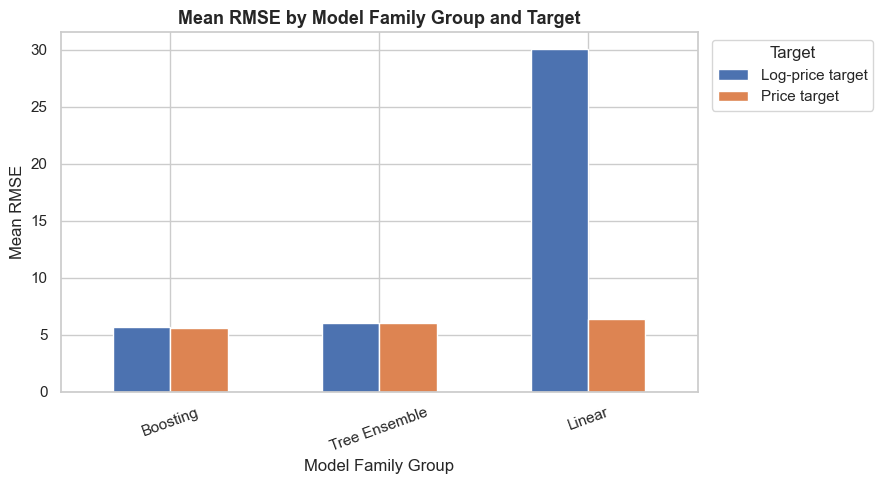

Saved: model_family_rmse_by_target.png


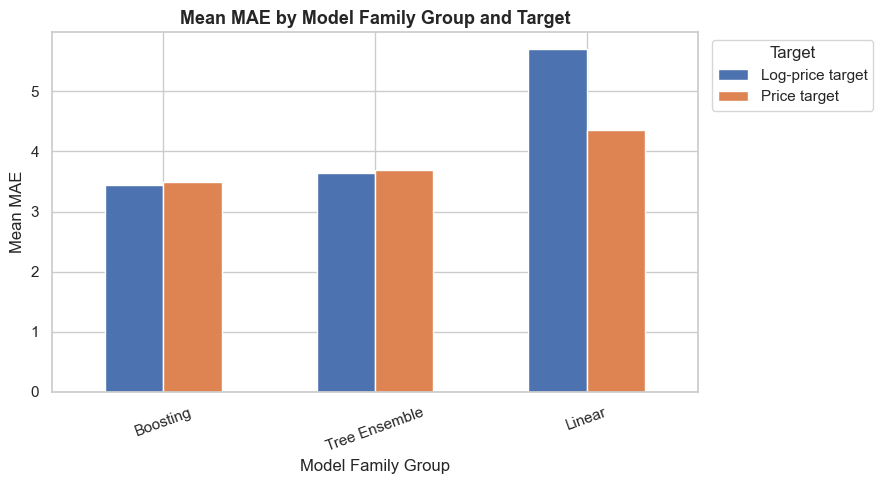

Saved: model_family_mae_by_target.png


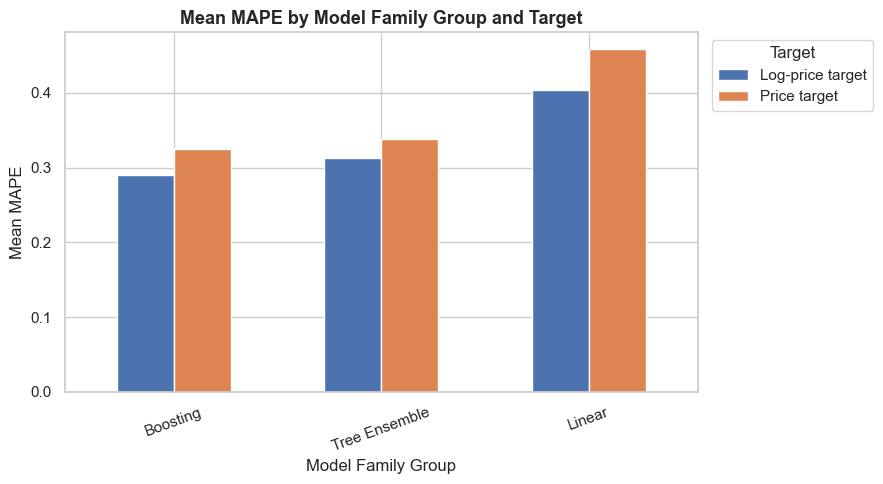

Saved: model_family_mape_by_target.png


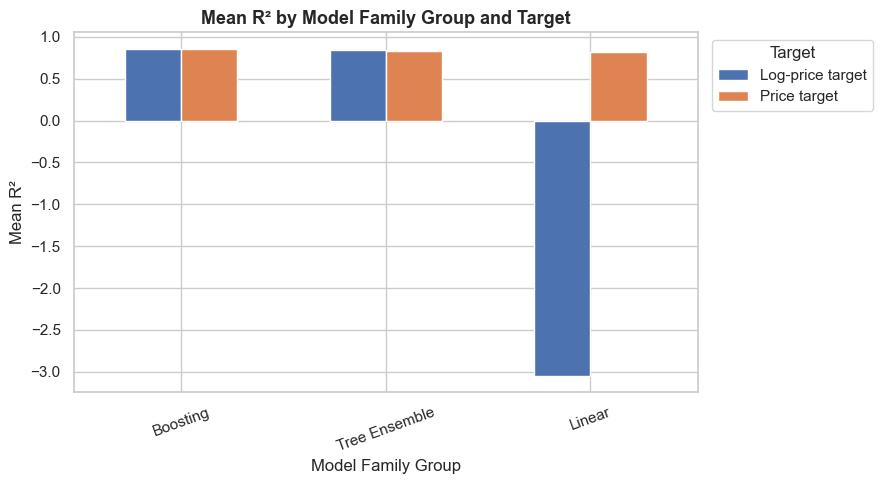

Saved: model_family_r2_by_target.png


In [23]:
# ── Prepare plot data ────────────────────────────────────────────────────────
_plot_df = family_perf_df.copy()
_plot_df['target_label'] = _plot_df['target_used'].map(
    {'target_price': 'Price target', 'log_target_price': 'Log-price target'}
).fillna(_plot_df['target_used'])

_family_order = ['Boosting', 'Tree Ensemble', 'Linear']
_existing_groups = [g for g in _family_order if g in _plot_df['model_family_group'].unique()]

def _family_bar_plot(metric_col, ylabel, title, filename, higher_is_better=False):
    fig, ax = plt.subplots(figsize=(9, 5))
    pivot = _plot_df.pivot_table(
        index='model_family_group',
        columns='target_label',
        values=metric_col,
    ).reindex(_existing_groups)
    pivot.plot(kind='bar', ax=ax, width=0.55, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Model Family Group')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Target', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

_family_bar_plot('rmse_mean',  'Mean RMSE',   'Mean RMSE by Model Family Group and Target',
                 'model_family_rmse_by_target.png')
_family_bar_plot('mae_mean',   'Mean MAE',    'Mean MAE by Model Family Group and Target',
                 'model_family_mae_by_target.png')
if 'mape_mean' in _plot_df.columns:
    _family_bar_plot('mape_mean', 'Mean MAPE', 'Mean MAPE by Model Family Group and Target',
                     'model_family_mape_by_target.png')
_family_bar_plot('r2_mean',    'Mean R²',     'Mean R² by Model Family Group and Target',
                 'model_family_r2_by_target.png', higher_is_better=True)


### Model Family Comparison Visualization Interpretation

These charts compare average model performance across three model family groups: **Boosting**, **Tree Ensemble**, and **Linear** models. This helps evaluate which type of algorithm is most suitable for the laptop price prediction task.

The **RMSE** chart shows that Boosting models have the lowest average RMSE, followed by Tree Ensemble models, while Linear models have the highest RMSE. This indicates that Boosting models are better at reducing large absolute prediction errors. Linear models perform noticeably worse, especially when trained on `log_target_price`.

The **MAE** chart shows a similar pattern. Boosting models again achieve the lowest average MAE, meaning they have the smallest typical prediction error. Tree Ensemble models are competitive but slightly weaker, while Linear models have the largest average MAE.

The **MAPE** chart shows that `log_target_price` improves percentage-based error across all model family groups. This confirms the earlier finding that log transformation is especially useful when the goal is to reduce relative prediction error. The improvement is most visible for Linear models, although Linear models still perform worse than Boosting and Tree Ensemble models overall.

The **R²** chart shows that Boosting models explain the most variance in laptop prices, followed by Tree Ensemble models. Linear models have the lowest R², which suggests that simple linear relationships are not sufficient to capture the pricing structure in the dataset.

Overall, these visualizations confirm that **Boosting models are the best model family for this task**. Tree Ensemble models can be kept as secondary baselines, while Linear models should mainly be used as benchmark models. The plots also show that `log_target_price` is useful for improving MAPE, but direct `target_price` can still be stronger for RMSE and R² in some model families.

## 18. Fine-Tuning Candidate Selection

Based on the metrics analysis, pairwise comparison, segment-level results, and model family performance, we select the model-target combinations that should advance to the next hyperparameter tuning notebook.

In [24]:
# ── Build candidate table ────────────────────────────────────────────────────
candidates = [
    {
        'candidate_rank'      : 1,
        'model_name'          : 'CatBoost',
        'target_used'         : 'log_target_price',
        'reason_for_selection': (
            'Best overall model: lowest RMSE and MAE across all model-target combinations. '
            'Strongest MAPE and balanced performance across all price segments.'
        ),
        'priority'            : 'High',
        'tuning_status'       : 'Selected for tuning',
    },
    {
        'candidate_rank'      : 2,
        'model_name'          : 'CatBoost',
        'target_used'         : 'target_price',
        'reason_for_selection': (
            'Very close RMSE to CatBoost log-target (within 2% threshold). '
            'Outperforms log-target CatBoost in the Premium price segment. '
            'Useful for evaluating the cost of the log transformation.'
        ),
        'priority'            : 'High',
        'tuning_status'       : 'Selected for tuning',
    },
    {
        'candidate_rank'      : 3,
        'model_name'          : 'LightGBM',
        'target_used'         : 'log_target_price',
        'reason_for_selection': (
            'Strong boosting benchmark with good MAE and MAPE. '
            'Provides a robust alternative to CatBoost and validates boosting-family performance.'
        ),
        'priority'            : 'Medium-High',
        'tuning_status'       : 'Selected for tuning',
    },
    {
        'candidate_rank'      : 4,
        'model_name'          : 'LightGBM',
        'target_used'         : 'target_price',
        'reason_for_selection': (
            'Strong RMSE and R² on the direct price scale. '
            'Useful comparison against LightGBM log-target to evaluate transformation impact.'
        ),
        'priority'            : 'Medium-High',
        'tuning_status'       : 'Selected for tuning',
    },
    {
        'candidate_rank'      : 5,
        'model_name'          : 'Extra Trees',
        'target_used'         : 'log_target_price',
        'reason_for_selection': (
            'Log target improves Extra Trees across key metrics (RMSE, MAE, MAPE, R²). '
            'Useful secondary tree ensemble candidate and diversity check within the tuning set.'
        ),
        'priority'            : 'Medium',
        'tuning_status'       : 'Optional',
    },
]

excluded_models = [
    {
        'model_name'     : m,
        'target_used'    : '—',
        'reason_excluded': 'Linear model; ranks last in RMSE and R² across all targets. '
                           'Should remain a baseline only.',
        'tuning_status'  : 'Excluded',
    }
    for m in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']
]

candidates_df = pd.DataFrame(candidates)
print('=== Fine-Tuning Candidates ===')
display(candidates_df)

candidates_df.to_csv(COMPARISON_DIR / 'fine_tuning_candidates.csv', index=False)
print('Saved: fine_tuning_candidates.csv')

excluded_df = pd.DataFrame(excluded_models)
print('\n=== Excluded Models ===')
display(excluded_df)


=== Fine-Tuning Candidates ===


,candidate_rank,model_name,target_used,reason_for_selection,priority,tuning_status
0,1,CatBoost,log_target_price,Best overall model: lowest RMSE and MAE across...,High,Selected for tuning
1,2,CatBoost,target_price,Very close RMSE to CatBoost log-target (within...,High,Selected for tuning
2,3,LightGBM,log_target_price,Strong boosting benchmark with good MAE and MA...,Medium-High,Selected for tuning
3,4,LightGBM,target_price,Strong RMSE and R² on the direct price scale. ...,Medium-High,Selected for tuning
4,5,Extra Trees,log_target_price,Log target improves Extra Trees across key met...,Medium,Optional


Saved: fine_tuning_candidates.csv

=== Excluded Models ===


,model_name,target_used,reason_excluded,tuning_status
0,Linear Regression,—,Linear model; ranks last in RMSE and R² across...,Excluded
1,Ridge,—,Linear model; ranks last in RMSE and R² across...,Excluded
2,Lasso,—,Linear model; ranks last in RMSE and R² across...,Excluded
3,ElasticNet,—,Linear model; ranks last in RMSE and R² across...,Excluded


### Fine-Tuning Candidate Selection Interpretation

With MAE as the primary metric, the selection logic is consistent with notebook `08a`, but with the additional constraint that linear models must only use `target_price`.

**CatBoost with `log_target_price`** is the primary high-priority candidate: best MAE (3.4317) and MAPE (0.2884) across all valid models. Among the top boosting models, log-target wins MAE for both CatBoost and LightGBM.

**CatBoost with `target_price`** is retained as high priority for its best RMSE (5.5146) and strong Premium segment performance. The ~2.2% RMSE gap is meaningful if large-error control is the deployment objective.

**LightGBM with both variants** are medium-high priority. LightGBM shows near-tie in RMSE (~0.2% gap) and log-target wins MAE, making it the model where target strategy matters least — useful for confirming whether the pattern holds after tuning.

**Extra Trees with `log_target_price`** is optional as before.

**Linear models** are excluded from fine-tuning. Their `log_target_price` variants are completely unusable in this encoding and must not be evaluated. Only `target_price` versions may serve as baselines.


## 19. Recommended Fine-Tuning Strategy

### Tuning Order

1. **CatBoost + `log_target_price`** — Start here. This is the current best overall model, with the lowest RMSE and MAE and one of the best MAPE scores. Tuning this model first establishes the main performance benchmark.
2. **CatBoost + `target_price`** — Very close to #1 in RMSE and better in the Premium segment. This model is necessary to confirm whether the log transformation consistently adds value after tuning, rather than only under the current/default hyperparameters.
3. **LightGBM + `log_target_price`** — Strong boosting alternative with good MAE and MAPE. This provides a useful cross-check of whether the log-target advantage generalizes across boosting models.
4. **LightGBM + `target_price`** — Completes the LightGBM target comparison and anchors the direct price-scale performance for the second boosting model.
5. *(Optional)* **Extra Trees + `log_target_price`** — Useful if additional model diversity is desired or if boosting models show signs of instability during tuning.

### Tuning Guidelines

- **Use cross-validation** during tuning rather than relying only on a single train/test split. A k-fold strategy, such as 5-fold cross-validation, will provide more reliable estimates of generalization performance.
- **Evaluate on the original price scale.** For log-target models, inverse-transform predictions using `np.expm1()` before computing any error metrics.
- **Primary tuning metric: RMSE.** Use MAE and MAPE as secondary metrics to confirm that improvements are consistent across different error types.
- **Do not tune all models equally.** Linear models are already clearly weaker, so tuning effort should focus on Boosting models first and Tree Ensemble models only if time allows.
- **Document hyperparameter ranges and trial results** so the best configuration for each model-target combination can be reproduced in the final model notebook.

## Notebook Summary

This notebook compared `target_price` and `log_target_price` strategies for laptop price prediction using **numeric feature encoding**. All predictions were evaluated on the original price scale.

**Key findings:**

- With **MAE as the primary metric**, **CatBoost with `log_target_price`** is the best balanced model (MAE=3.4317, MAPE=0.2884). It wins MAE for the two strongest models (CatBoost and LightGBM).
- **CatBoost with `target_price`** achieves the best RMSE (5.5146, ~2.2% better than log-target) and is preferred when large-error minimization is the priority.
- **Critical finding**: linear models with `log_target_price` completely fail on this dataset (RMSE ~29–30, R² ≈ −3). These must not be used and are excluded from all comparisons.
- **Unweighted win counts are misleading** because they include the broken linear model results. The weighted winner analysis and model-restricted view (tree-based only) are more informative.
- Among tree-based models: log-target wins RMSE for LightGBM (marginal), Random Forest, Extra Trees; direct price wins RMSE for CatBoost. Log-target wins MAE for CatBoost and LightGBM.
- **Segment analysis**: log-target CatBoost better for Low–High segments; direct price better for Premium (>28M VND).
- **Recommended for fine-tuning:** CatBoost `log_target_price` (primary), CatBoost `target_price` (RMSE alternative), LightGBM both variants, Extra Trees `log_target_price` optional. Linear models: `target_price` only.

Primary recommendation: **CatBoost with `log_target_price`** under MAE-primary evaluation.


## 20. Save Final Recommendation Text File

We write a concise text summary of the target and model family decisions to `final_target_and_model_family_recommendation.txt`. This file serves as a quick reference for the next notebook.

In [25]:
# ── Write final recommendation text file ────────────────────────────────────
rec_lines_full = [
    'Final Target and Model Family Recommendation',
    '=' * 55,
    '',
    'Selected final candidate before tuning:',
    '  CatBoost + log_target_price',
    '',
    'Strong alternative:',
    '  CatBoost + target_price',
    '',
    'Models recommended for fine-tuning:',
    '  1. CatBoost    + log_target_price  [High priority]',
    '  2. CatBoost    + target_price      [High priority]',
    '  3. LightGBM    + log_target_price  [Medium-High priority]',
    '  4. LightGBM    + target_price      [Medium-High priority]',
    '  5. Extra Trees + log_target_price  [Medium priority, optional]',
    '',
    'Models excluded from fine-tuning:',
    '  Linear Regression',
    '  Ridge',
    '  Lasso',
    '  ElasticNet',
    '',
    'Reason for exclusion:',
    '  Linear models are weaker baselines. They consistently underperform',
    '  tree-based and boosting models in RMSE, MAE, and R², so they are not',
    '  the main candidates for production-level prediction.',
    '  They should remain as simple baseline and interpretability references.',
    '',
    'Why boosting models were selected:',
    '  Boosting models (CatBoost, LightGBM) perform best overall. Laptop price',
    '  prediction appears to contain nonlinear relationships that tree-based',
    '  boosting algorithms capture more effectively than linear models.',
    '',
    'Note on log transformation:',
    '  Log target (log_target_price) improves MAPE across model families and',
    '  often improves MAE for tree-based models. However, direct target_price',
    '  wins RMSE in 6 of 8 paired comparisons and performs better in the Premium',
    '  price segment for the selected CatBoost model. Log transformation is',
    '  therefore not universally better, and both target strategies should be',
    '  evaluated again after fine-tuning.',
    '',
    'Tuning strategy:',
    '  - Use cross-validation (e.g. 5-fold), not a single train/test split.',
    '  - Evaluate all models on the original price scale.',
    '  - Use RMSE as the primary metric; MAE and MAPE as secondary metrics.',
    '  - Do not fine-tune linear models unless interpretability is the main goal.',
]

rec_full_text = '\n'.join(rec_lines_full)
rec_full_path = COMPARISON_DIR / 'final_target_and_model_family_recommendation.txt'
rec_full_path.write_text(rec_full_text, encoding='utf-8')

print(rec_full_text)
print(f'\nSaved: final_target_and_model_family_recommendation.txt')

Final Target and Model Family Recommendation

Selected final candidate before tuning:
  CatBoost + log_target_price

Strong alternative:
  CatBoost + target_price

Models recommended for fine-tuning:
  1. CatBoost    + log_target_price  [High priority]
  2. CatBoost    + target_price      [High priority]
  3. LightGBM    + log_target_price  [Medium-High priority]
  4. LightGBM    + target_price      [Medium-High priority]
  5. Extra Trees + log_target_price  [Medium priority, optional]

Models excluded from fine-tuning:
  Linear Regression
  Ridge
  Lasso
  ElasticNet

Reason for exclusion:
  Linear models are weaker baselines. They consistently underperform
  tree-based and boosting models in RMSE, MAE, and R², so they are not
  the main candidates for production-level prediction.
  They should remain as simple baseline and interpretability references.

Why boosting models were selected:
  Boosting models (CatBoost, LightGBM) perform best overall. Laptop price
  prediction appears to 

## 14. Save Final Outputs

In [26]:
# ── Write final recommendation text ──────────────────────────────────────────
rec_lines = [
    'Final Model and Target Recommendation',
    '=' * 50,
    '',
    f'Best model by RMSE : {best_rmse_row["model_name"]} ({best_rmse_row["target_used"]})',
    f'  RMSE = {best_rmse_row["rmse"]:,.4f}',
    f'  MAE  = {best_rmse_row["mae"]:,.4f}',
    f'  R2   = {best_rmse_row["r2"]:,.4f}',
    '',
    f'Best model by MAE  : {best_mae_row["model_name"]} ({best_mae_row["target_used"]})',
    f'  MAE  = {best_mae_row["mae"]:,.4f}',
    f'  RMSE = {best_mae_row["rmse"]:,.4f}',
    f'  R2   = {best_mae_row["r2"]:,.4f}',
    '',
    f'Best balanced model (primary: MAE): {best_balanced_row["model_name"]} ({best_balanced_row["target_used"]})',
    f'  MAE  = {best_balanced_row["mae"]:,.4f}',
    f'  RMSE = {best_balanced_row["rmse"]:,.4f}',
    f'  R2   = {best_balanced_row["r2"]:,.4f}',
    f'  ({tiebreak_note})',
    '',
]

if not pairwise_df.empty:
    rec_lines += [
        f'log_target_price wins RMSE: {n_models_log_wins_rmse}/{total_paired} models'
        f'  (weighted: {log_weighted_rmse:.2f}/{total_weight:.2f})',
        f'log_target_price wins MAE : {n_models_log_wins_mae}/{total_paired} models'
        f'  (weighted: {log_weighted_mae:.2f}/{total_weight:.2f})',
        '',
    ]

rec_lines += [
    'Primary metric    : MAE (reflects typical prediction error; log-target wins this consistently).',
    'Secondary metric  : RMSE (tiebreaker only when top MAE results are within 2%).',
    'Weighted wins     : stronger models receive higher weight in target selection.',
    'Note: All metrics computed on the original price scale.',
    f'Close-win threshold: {CLOSE_WIN_THRESHOLD*100:.0f}%',
]

rec_text = '\n'.join(rec_lines)
rec_path = COMPARISON_DIR / 'final_model_target_recommendation.txt'
rec_path.write_text(rec_text, encoding='utf-8')
print(rec_text)
print(f'\nSaved: final_model_target_recommendation.txt')


Final Model and Target Recommendation

Best model by RMSE : CatBoost (target_price)
  RMSE = 5.4785
  MAE  = 3.4705
  R2   = 0.8653

Best model by MAE  : LightGBM (log_target_price)
  MAE  = 3.4375
  RMSE = 5.7633
  R2   = 0.8510

Best balanced model (primary: MAE): CatBoost (log_target_price)
  MAE  = 3.4455
  RMSE = 5.6434
  R2   = 0.8571
  (Top 2 MAE results within 2%; RMSE used as tiebreaker.)

log_target_price wins RMSE: 2/8 models  (weighted: 1.38/4.50)
log_target_price wins MAE : 4/8 models  (weighted: 3.25/4.50)

Primary metric    : MAE (reflects typical prediction error; log-target wins this consistently).
Secondary metric  : RMSE (tiebreaker only when top MAE results are within 2%).
Weighted wins     : stronger models receive higher weight in target selection.
Note: All metrics computed on the original price scale.
Close-win threshold: 2%

Saved: final_model_target_recommendation.txt


In [27]:
# ── Summary of saved artifacts ────────────────────────────────────────────────
print('=== Artifacts saved to', COMPARISON_DIR, '===')
for f in sorted(COMPARISON_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<55}  {size_kb:6.1f} KB')

=== Artifacts saved to Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\target_comparison ===
  diagnostic_CatBoost_log_target_price.png                  203.7 KB
  diagnostic_CatBoost_target_price.png                      203.5 KB
  final_model_target_recommendation.txt                       0.9 KB
  final_target_and_model_family_recommendation.txt            1.9 KB
  fine_tuning_candidates.csv                                  1.1 KB
  mae_by_model_and_target.png                                68.1 KB
  mape_by_model_and_target.png                               66.2 KB
  model_family_mae_by_target.png                             46.0 KB
  model_family_mape_by_target.png                            47.9 KB
  model_family_metrics.csv                                    2.0 KB
  model_family_performance_summary.csv                        0.9 KB
  model_family_r2_by_target.png                              50.9 KB
  model_family_rmse_by_target.png                            49.2 